# 1️⃣ 문제 정의 및 데이터 파악

<BIG><u>**에어비앤비의 신규 사용자가 어느 나라에서 첫 예약을 할지 예측하기</u></BIG>**

- 새로운 사용자 한 명당 첫 예약 국가에 대해 최대 5개의 예측을 수행해야 합니다.  
- 실제 예약 국가는 관련성 = 1로 표시되고, 나머지는 관련성 = 0으로 표시됩니다.  

## 1-1. 데이터셋 설명
이 과제에서는 사용자 목록과 함께 사용자 인구 통계 정보, 웹 세션 기록 및 일부 요약 통계가 제공됩니다.  
신규 사용자가 처음으로 예약할 국가를 예측해야 합니다. 이 데이터 세트의 모든 사용자는 미국 사용자입니다.  

목적지 국가는 'US', 'FR', 'CA', 'GB', 'ES', 'IT', 'PT', 'NL', 'DE', 'AU', 'NDF'(목적지를 찾을 수 없음),  
'other'의 12가지 가능한 결과가 있습니다. 'NDF'는 예약은 되었지만 목록에 없는 국가로 가는 경우를 의미하고,  
'NDF'는 예약이 없는 경우를 의미합니다.  

훈련 데이터셋과 테스트 데이터셋은 날짜별로 구분되어 있습니다.  
테스트 데이터셋에서는 2014년 7월 1일 이후 첫 활동을 기록한 모든 신규 사용자를 예측해야 합니다  
(참고: 이 데이터는 대회가 재개된 2015년 12월 5일을 기준으로 업데이트되었습니다).  
세션 데이터셋은 2014년 1월 1일부터의 데이터만 포함하고 있으며,  
사용자 데이터셋은 2010년까지의 데이터를 포함합니다.   

## 1-2. 파일 설명
- train_users.csv : 사용자 학습 데이터 세트  
- test_users.csv : 테스트 사용자 데이터 세트  
    - `id` : 사용자 ID  
    - `date_account_created` : 계정 생성 날짜  
    - `timestamp_first_active` : 첫 번째 활동의 타임스탬프  
    (사용자가 가입 전에 검색할 수 있으므로 `date_account_created`  
    또는 `date_first_booking`보다 이전일 수 있음)  
    - `date_first_booking` : 첫 예약 날짜  
    - `gender`,	`age`  
    - `signup_method` : 가입 방법  
    - `signup_flow` : 사용자가 회원가입을 하기 위해 방문한 페이지  
    - `language` : 언어 (국제 언어 선호)  
    - `affiliate_channel` : 어떤 종류의 유료 마케팅인가요?  
    - `affiliate_provider` : 마케팅이 이루어지는 곳 (예: Google, Craigslist 등)  
    - `first_affiliate_tracked` : 사용자가 가입하기 전에 처음으로 접한 마케팅은 무엇인가요?  
    - `signup_app` : 회원가입_앱  
    - `first_device_type`	: 첫 번째 장치 유형  
    - `first_browser` : 첫 번째 브라우저  
<br>
- `country_destination` : 예측해야 할 목표 변수  
<br>
- sessions.csv : 사용자 웹 세션 로그  
    - `user_id` : users 테이블의 'id' 열과 조인될 열  
    - `action` : 행동  
    - `action_type` : 액션 유형  
    - `action_detail` : 액션_디테일  
    - `device_type` : 장치 유형  
    - `secs_elapsed` : 경과 시간(초)  
<br>
- countries.csv : 이 데이터 세트에 포함된 목적지 국가 및 해당 위치에 대한 요약 통계  
- age_gender_bkts.csv : 사용자의 연령대, 성별, 여행 국가에 대한 요약 통계  
- sample_submission.csv : 예측 제출을 위한 올바른 파일 형식  

## 1-3. 파일 로드 및 개요 확인

In [1]:
# 파이썬 라이브러리 및 모듈 가져오기
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings('ignore')

# 기본 폰트 설정 / 계속된 오류로 코드 변경
# plt.rcParams['font.family'] = 'AppleGothic'  # 기본 폰트 설정 (macOS)
font_path = r"C:\Users\jm\AppData\Local\Microsoft\Windows\Fonts\NanumGothic.ttf"
fm.fontManager.addfont(font_path)                 # 폰트 등록
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["font.family"] = font_name           # 전체 기본 폰트로 지정
plt.rcParams["axes.unicode_minus"] = False

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# 주어진 파일 로드 & 파일 확인
bnb_sessions_df = pd.read_csv('sessions.csv')
bnb_tst_df = pd.read_csv('test_users.csv')
bnb_train_df = pd.read_csv('train_users_2.csv')
bnb_agb_df = pd.read_csv('age_gender_bkts.csv')
bnb_country_df = pd.read_csv('countries.csv')

print("sessions :")
display(bnb_sessions_df)
print("\ntest_users :")
display(bnb_tst_df)
print("\ntrain_users_2 :")
display(bnb_train_df)
print("\nage_gender_bkts :")
display(bnb_agb_df)
print("\ncountries :")
display(bnb_country_df)

sessions :


,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0
3,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,22141.0
4,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,435.0
...,...,...,...,...,...,...
10567732,9uqfg8txu3,dashboard,view,dashboard,Windows Desktop,556.0
10567733,9uqfg8txu3,edit,view,edit_profile,Windows Desktop,6624.0
10567734,9uqfg8txu3,webcam_upload,-unknown-,-unknown-,Windows Desktop,200125.0
10567735,9uqfg8txu3,active,-unknown-,-unknown-,-unknown-,17624.0



test_users :


,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser
0,5uwns89zht,2014-07-01,20140701000006,NaN,FEMALE,35.0,facebook,0,en,direct,direct,untracked,Moweb,iPhone,Mobile Safari
1,jtl0dijy2j,2014-07-01,20140701000051,NaN,-unknown-,NaN,basic,0,en,direct,direct,untracked,Moweb,iPhone,Mobile Safari
2,xx0ulgorjt,2014-07-01,20140701000148,NaN,-unknown-,NaN,basic,0,en,direct,direct,linked,Web,Windows Desktop,Chrome
3,6c6puo6ix0,2014-07-01,20140701000215,NaN,-unknown-,NaN,basic,0,en,direct,direct,linked,Web,Windows Desktop,IE
4,czqhjk3yfe,2014-07-01,20140701000305,NaN,-unknown-,NaN,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Safari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62091,cv0na2lf5a,2014-09-30,20140930235232,NaN,-unknown-,31.0,basic,0,en,direct,direct,untracked,Web,Windows Desktop,IE
62092,zp8xfonng8,2014-09-30,20140930235306,NaN,-unknown-,NaN,basic,23,ko,direct,direct,untracked,Android,Android Phone,-unknown-
62093,fa6260ziny,2014-09-30,20140930235408,NaN,-unknown-,NaN,basic,0,de,direct,direct,linked,Web,Windows Desktop,Firefox
62094,87k0fy4ugm,2014-09-30,20140930235430,NaN,-unknown-,NaN,basic,0,en,sem-brand,google,omg,Web,Mac Desktop,Safari



train_users_2 :


,id,date_account_created,timestamp_first_active,date_first_booking,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination
0,gxn3p5htnn,2010-06-28,20090319043255,NaN,-unknown-,NaN,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,NDF
1,820tgsjxq7,2011-05-25,20090523174809,NaN,MALE,38.0,facebook,0,en,seo,google,untracked,Web,Mac Desktop,Chrome,NDF
2,4ft3gnwmtx,2010-09-28,20090609231247,2010-08-02,FEMALE,56.0,basic,3,en,direct,direct,untracked,Web,Windows Desktop,IE,US
3,bjjt8pjhuk,2011-12-05,20091031060129,2012-09-08,FEMALE,42.0,facebook,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,other
4,87mebub9p4,2010-09-14,20091208061105,2010-02-18,-unknown-,41.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Chrome,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213446,zxodksqpep,2014-06-30,20140630235636,NaN,MALE,32.0,basic,0,en,sem-brand,google,omg,Web,Mac Desktop,Safari,NDF
213447,mhewnxesx9,2014-06-30,20140630235719,NaN,-unknown-,NaN,basic,0,en,direct,direct,linked,Web,Windows Desktop,Chrome,NDF
213448,6o3arsjbb4,2014-06-30,20140630235754,NaN,-unknown-,32.0,basic,0,en,direct,direct,untracked,Web,Mac Desktop,Firefox,NDF
213449,jh95kwisub,2014-06-30,20140630235822,NaN,-unknown-,NaN,basic,25,en,other,other,tracked-other,iOS,iPhone,Mobile Safari,NDF



age_gender_bkts :


,age_bucket,country_destination,gender,population_in_thousands,year
0,100+,AU,male,1.0,2015.0
1,95-99,AU,male,9.0,2015.0
2,90-94,AU,male,47.0,2015.0
3,85-89,AU,male,118.0,2015.0
4,80-84,AU,male,199.0,2015.0
...,...,...,...,...,...
415,95-99,US,male,115.0,2015.0
416,90-94,US,male,541.0,2015.0
417,15-19,US,female,10570.0,2015.0
418,85-89,US,male,1441.0,2015.0



countries :


,country_destination,lat_destination,lng_destination,distance_km,destination_km2,destination_language,language_levenshtein_distance
0,AU,-26.853388,133.275160,15297.7440,7741220.0,eng,0.00
1,CA,62.393303,-96.818146,2828.1333,9984670.0,eng,0.00
2,DE,51.165707,10.452764,7879.5680,357022.0,deu,72.61
3,ES,39.896027,-2.487694,7730.7240,505370.0,spa,92.25
4,FR,46.232193,2.209667,7682.9450,643801.0,fra,92.06
5,GB,54.633220,-3.432277,6883.6590,243610.0,eng,0.00
6,IT,41.873990,12.564167,8636.6310,301340.0,ita,89.40
7,NL,52.133057,5.295250,7524.3203,41543.0,nld,63.22
8,PT,39.553444,-7.839319,7355.2534,92090.0,por,95.45
9,US,36.966427,-95.844030,0.0000,9826675.0,eng,0.00


In [3]:
print("🔹sessions :", bnb_train_df.shape)
bnb_sessions_df.info()

print("\n🔹test_users :", bnb_tst_df.shape)
bnb_tst_df.info()

print("\n🔹train_users_2 :", bnb_train_df.shape)
bnb_train_df.info()

print("\n🔹age_gender_bkts :", bnb_agb_df.shape)
bnb_agb_df.info()

print("\n🔹countries :", bnb_country_df.shape)
bnb_country_df.info()


🔹sessions : (213451, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10567737 entries, 0 to 10567736
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_id        object 
 1   action         object 
 2   action_type    object 
 3   action_detail  object 
 4   device_type    object 
 5   secs_elapsed   float64
dtypes: float64(1), object(5)
memory usage: 483.8+ MB

🔹test_users : (62096, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62096 entries, 0 to 62095
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       62096 non-null  object 
 1   date_account_created     62096 non-null  object 
 2   timestamp_first_active   62096 non-null  int64  
 3   date_first_booking       0 non-null      float64
 4   gender                   62096 non-null  object 
 5   age                      33220 non-null  float64
 6   signup_met

---

## 1-4. 기본 EDA

누구인가? (인적 사항): gender(성별), age(나이), language(언어)

언제 가입했나? (시간): date_account_created(가입일), timestamp_first_active(첫활동)

어떻게 들어왔나? (유입 경로): signup_method(가입방식), affiliate_channel(마케팅경로), signup_app(웹/앱 여부)

무엇을 썼나? (기기 환경): first_device_type(맥/아이폰/PC), first_browser(크롬/사파리)

판단: "어떤 환경(기기)에서 어떤 경로로 들어온, 몇 살의 유저가 어디를 갈까?"를 맞추는 것이 이 프로젝트 목적

---

# 2️⃣ Data Cleaning

## 2-1. 알파벳 정리

- user, session, age_gender_bkts, countries 파일  
- object : 대문자 → 소문자
- id는 식별자이므로 제외하고 진행

In [4]:
def lower_object_cols(df, exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []

    obj_cols = [c for c in df.columns if df[c].dtype == 'object' and c not in exclude_cols]

    for c in obj_cols:
        s = df[c]
        # 문자열인 값만 lower, 나머지는 그대로 둠
        mask = s.map(lambda x: isinstance(x, str))
        df.loc[mask, c] = s.loc[mask].str.lower()

    return df

for df in [bnb_train_df, bnb_tst_df, bnb_agb_df, bnb_country_df]:
    exclude = [c for c in ['id', 'user_id'] if c in df.columns]
    lower_object_cols(df, exclude_cols=exclude)

## 2-2. user 파일

### 2-2-1. 날짜 Datetime 처리  
- Train / Test 파일이 의도적으로 시간 순서로 잘려있음을 확인  
    - train : 2010-01-01 ~ 2014-06-30  
    - test : 2014-07-01 ~ 2014-09-30 

In [5]:
bnb_train_df.sort_values(by='date_account_created', ascending=False)[['date_account_created']]

,date_account_created
213450,2014-06-30
213045,2014-06-30
213061,2014-06-30
213060,2014-06-30
213059,2014-06-30
...,...
10,2010-01-04
9,2010-01-04
7,2010-01-03
6,2010-01-02


In [6]:
bnb_tst_df.sort_values(by='date_account_created', ascending=False)[['date_account_created']]

,date_account_created
62095,2014-09-30
61626,2014-09-30
61634,2014-09-30
61633,2014-09-30
61632,2014-09-30
...,...
400,2014-07-01
399,2014-07-01
398,2014-07-01
397,2014-07-01


- `date_account_created` 가입시점을 나타내는 컬럼  
    - 날짜를 모두 남길 필요 없으므로 연월/요일 컬럼 2개로 변환  
    → `dac_ym`, `dac_weekday` 컬럼 생성

In [7]:
from datetime import datetime

for df in [bnb_train_df, bnb_tst_df]:
    df['date_account_created'] = pd.to_datetime(df['date_account_created'], errors='coerce')

for df in [bnb_train_df, bnb_tst_df]:
    bnb_train_df['dac_ym'] = bnb_train_df['date_account_created'].dt.to_period('M')
    df['dac_weekday'] = df['date_account_created'].dt.dayofweek # 0: 월요일 ~ 6: 일요일

bnb_train_df[['dac_ym', 'dac_weekday']]

,dac_ym,dac_weekday
0,2010-06,0
1,2011-05,2
2,2010-09,1
3,2011-12,0
4,2010-09,1
...,...,...
213446,2014-06,0
213447,2014-06,0
213448,2014-06,0
213449,2014-06,0


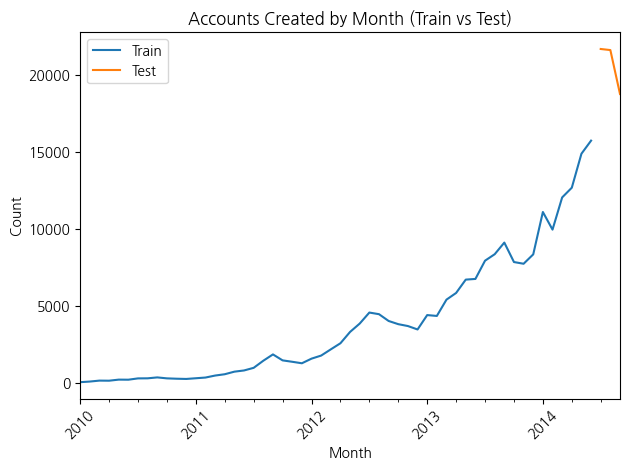

In [8]:
# Train
tmp_train = bnb_train_df.dropna(subset=['date_account_created']).copy()
tmp_train['dac_month'] = tmp_train['date_account_created'].dt.to_period('M')
train_counts = tmp_train['dac_month'].value_counts().sort_index()

# Test
tmp_test = bnb_tst_df.dropna(subset=['date_account_created']).copy()
tmp_test['dac_month'] = tmp_test['date_account_created'].dt.to_period('M')
test_counts = tmp_test['dac_month'].value_counts().sort_index()

# 그래프
plt.figure()
train_counts.plot(kind='line', label='Train')
test_counts.plot(kind='line', label='Test')

plt.title("Accounts Created by Month (Train vs Test)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

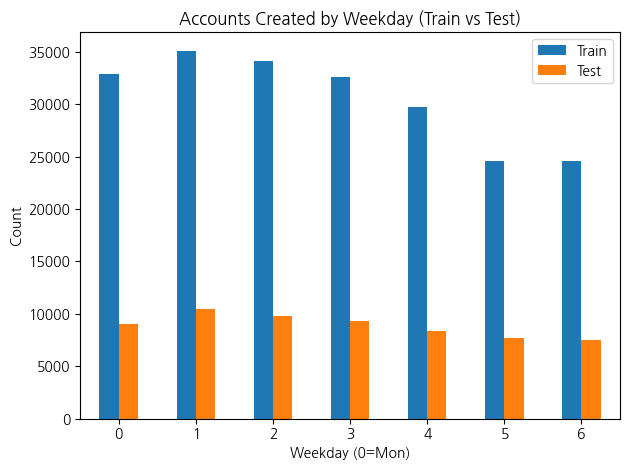

In [9]:
# 0~6 정렬
train_counts = (
    bnb_train_df['dac_weekday']
    .value_counts()
    .reindex(range(7), fill_value=0)
)

test_counts = (
    bnb_tst_df['dac_weekday']
    .value_counts()
    .reindex(range(7), fill_value=0)
)

weekday_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

plt.figure()
weekday_df.plot(kind='bar')
plt.title("Accounts Created by Weekday (Train vs Test)")
plt.xlabel("Weekday (0=Mon)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- `timestamp_first_active`는 년/월/시/분/초 단위까지 있음  
사용자 행동 시간대(몇 시에 처음 활동했는지)만 남겨도 괜찮다고 판단  
→ `tfa_hour` 컬럼 생성

In [10]:
for df in [bnb_train_df, bnb_tst_df]:

    # timestamp 변환
    df['timestamp_first_active'] = pd.to_datetime(
        df['timestamp_first_active'],
        format='%Y%m%d%H%M%S'
    )

    # 시간 feature
    df['tfa_hour'] = df['timestamp_first_active'].dt.hour

bnb_train_df['tfa_hour']

0          4
1         17
2         23
3          6
4          6
          ..
213446    23
213447    23
213448    23
213449    23
213450    23
Name: tfa_hour, Length: 213451, dtype: int32

<Figure size 640x480 with 0 Axes>

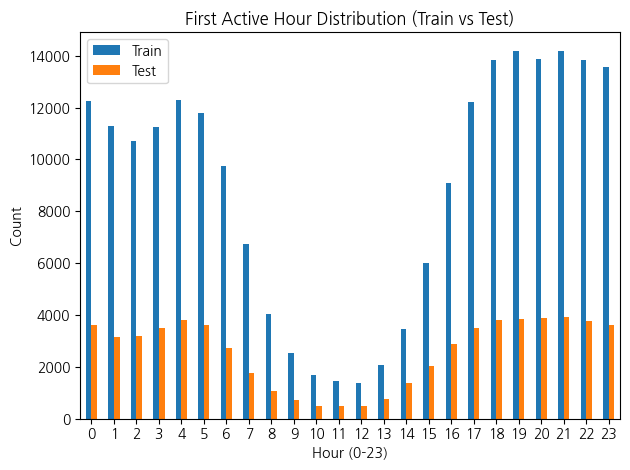

In [11]:
# Train
train_counts = (
    bnb_train_df['tfa_hour']
    .value_counts()
    .reindex(range(24), fill_value=0)
    .sort_index()
)

# Test
test_counts = (
    bnb_tst_df['tfa_hour']
    .value_counts()
    .reindex(range(24), fill_value=0)
    .sort_index()
)

# 하나의 DataFrame으로 묶기
hour_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

plt.figure()
hour_df.plot(kind='bar')
plt.title("First Active Hour Distribution (Train vs Test)")
plt.xlabel("Hour (0-23)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

- 가입일, 첫 활동일 간격 컬럼 생성  
(첫 활동이 가입보다 빠를 수도 있다고 했으므로, 절대값 처리)  
`dac_tfa_days` = 계정생성일 - 첫활성시간  

- 계정생성일 - 첫활성시간 : 사용자의 의도   
    - 음수 : 가입 전에 이미 탐색 → 적극적  
    - 0 : 가입 직후 활동  
    - 양수 : 가입 후 며칠 뒤 활동 → 소극적  

In [12]:
for df in [bnb_train_df, bnb_tst_df]:

    # timestamp 변환
    df['timestamp_first_active'] = pd.to_datetime(
        df['timestamp_first_active'],
        format='%Y%m%d%H%M%S'
    )

    # account created 변환
    df['date_account_created'] = pd.to_datetime(df['date_account_created'])

    # 날짜 차이 (일 단위)
    df['dac_tfa_days'] = (
        df['date_account_created'] -
        df['timestamp_first_active'].dt.normalize()    # timestamp_first_active의 날짜만 남김
    ).dt.days

bnb_train_df['dac_tfa_days']

0         466
1         732
2         476
3         765
4         280
         ... 
213446      0
213447      0
213448      0
213449      0
213450      0
Name: dac_tfa_days, Length: 213451, dtype: int64

In [13]:
bnb_train_df['dac_tfa_days'].describe()

count    213451.000000
mean          0.231819
std          11.948395
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max        1456.000000
Name: dac_tfa_days, dtype: float64

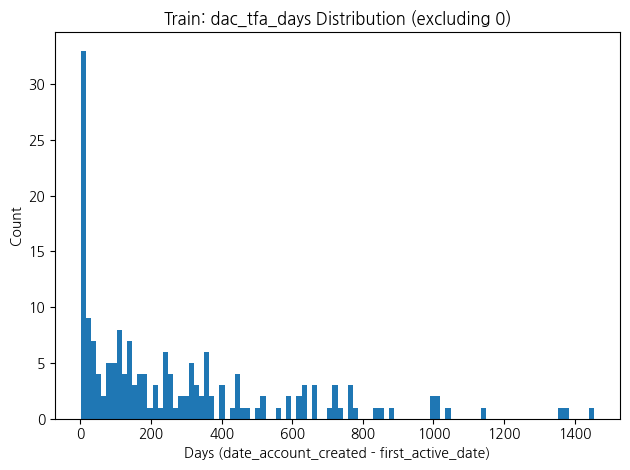

In [14]:
plt.figure()
plt.hist(bnb_train_df['dac_tfa_days'][bnb_train_df['dac_tfa_days'] > 0], bins=100)
plt.title("Train: dac_tfa_days Distribution (excluding 0)")
plt.xlabel("Days (date_account_created - first_active_date)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

- `date_first_booking`  
    <br>
    - test 파일에서는 모두 결측치로 존재하는 값  
    train에도 약 58%의 결측치 확인  
    → 예약이 발생했다는 사실 자체가 타겟과 직접 연결된 정보이므로  
    → 미래 정보가 섞일 가능성 매우 높으므로 컬럼 삭제  

In [15]:
bnb_train_df.isna().mean()

id                         0.000000
date_account_created       0.000000
timestamp_first_active     0.000000
date_first_booking         0.583473
gender                     0.000000
age                        0.412226
signup_method              0.000000
signup_flow                0.000000
language                   0.000000
affiliate_channel          0.000000
affiliate_provider         0.000000
first_affiliate_tracked    0.028414
signup_app                 0.000000
first_device_type          0.000000
first_browser              0.000000
country_destination        0.000000
dac_ym                     0.000000
dac_weekday                0.000000
tfa_hour                   0.000000
dac_tfa_days               0.000000
dtype: float64

In [16]:
for df in [bnb_train_df, bnb_tst_df]:
    df.drop(columns=['date_first_booking'], inplace=True)

- 날짜 처리하면서 필요없어진 컬럼 삭제  
`timestamp_first_active`, `date_account_created`

In [17]:
# timestamp_first_active 컬럼 삭제
for df in [bnb_train_df, bnb_tst_df]:
    df.drop(columns=['timestamp_first_active'], inplace=True)

# date_account_created 컬럼 삭제
for df in [bnb_train_df, bnb_tst_df]:
    df.drop(columns=['date_account_created'], inplace=True)

In [18]:
bnb_train_df

,id,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,country_destination,dac_ym,dac_weekday,tfa_hour,dac_tfa_days
0,gxn3p5htnn,-unknown-,NaN,facebook,0,en,direct,direct,untracked,web,mac desktop,chrome,ndf,2010-06,0,4,466
1,820tgsjxq7,male,38.0,facebook,0,en,seo,google,untracked,web,mac desktop,chrome,ndf,2011-05,2,17,732
2,4ft3gnwmtx,female,56.0,basic,3,en,direct,direct,untracked,web,windows desktop,ie,us,2010-09,1,23,476
3,bjjt8pjhuk,female,42.0,facebook,0,en,direct,direct,untracked,web,mac desktop,firefox,other,2011-12,0,6,765
4,87mebub9p4,-unknown-,41.0,basic,0,en,direct,direct,untracked,web,mac desktop,chrome,us,2010-09,1,6,280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213446,zxodksqpep,male,32.0,basic,0,en,sem-brand,google,omg,web,mac desktop,safari,ndf,2014-06,0,23,0
213447,mhewnxesx9,-unknown-,NaN,basic,0,en,direct,direct,linked,web,windows desktop,chrome,ndf,2014-06,0,23,0
213448,6o3arsjbb4,-unknown-,32.0,basic,0,en,direct,direct,untracked,web,mac desktop,firefox,ndf,2014-06,0,23,0
213449,jh95kwisub,-unknown-,NaN,basic,25,en,other,other,tracked-other,ios,iphone,mobile safari,ndf,2014-06,0,23,0


In [19]:
bnb_tst_df

,id,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,dac_weekday,tfa_hour,dac_tfa_days
0,5uwns89zht,female,35.0,facebook,0,en,direct,direct,untracked,moweb,iphone,mobile safari,1,0,0
1,jtl0dijy2j,-unknown-,NaN,basic,0,en,direct,direct,untracked,moweb,iphone,mobile safari,1,0,0
2,xx0ulgorjt,-unknown-,NaN,basic,0,en,direct,direct,linked,web,windows desktop,chrome,1,0,0
3,6c6puo6ix0,-unknown-,NaN,basic,0,en,direct,direct,linked,web,windows desktop,ie,1,0,0
4,czqhjk3yfe,-unknown-,NaN,basic,0,en,direct,direct,untracked,web,mac desktop,safari,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62091,cv0na2lf5a,-unknown-,31.0,basic,0,en,direct,direct,untracked,web,windows desktop,ie,1,23,0
62092,zp8xfonng8,-unknown-,NaN,basic,23,ko,direct,direct,untracked,android,android phone,-unknown-,1,23,0
62093,fa6260ziny,-unknown-,NaN,basic,0,de,direct,direct,linked,web,windows desktop,firefox,1,23,0
62094,87k0fy4ugm,-unknown-,NaN,basic,0,en,sem-brand,google,omg,web,mac desktop,safari,1,23,0


---

### 2-2-2. Age 구간화 처리

  - Age 10년 단위로 구간화 분류  
  age_gender_bkts.csv에서 5년 단위로 구간화 되어있으므로  
  (15 미만 & 100 이상은 이상치 처리)

age describe: count    125461.000000
mean         49.668335
std         155.666612
min           1.000000
25%          28.000000
50%          34.000000
75%          43.000000
max        2014.000000
Name: age, dtype: float64
age < 0: 0  / age > 100: 2345
age missing: 87990


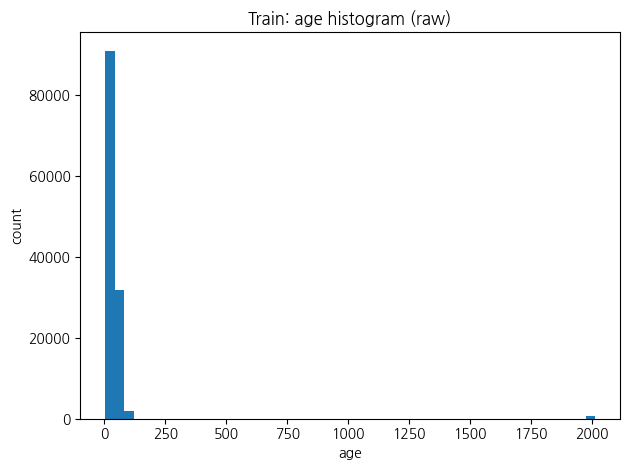

In [20]:
if "age" in bnb_train_df.columns:
    age = bnb_train_df["age"]
    print("age describe:", age.describe())
    print("age < 0:", (age < 0).sum(), " / age > 100:", (age > 100).sum())
    print("age missing:", age.isna().sum())
    
    plt.figure()
    age.dropna().plot(kind="hist", bins=50)
    plt.title("Train: age histogram (raw)")
    plt.xlabel("age")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

In [21]:
# 이상치 제거
for df in [bnb_train_df, bnb_tst_df]:
    df.loc[(df['age'] < 15) | (df['age'] > 100), 'age'] = np.nan

# 결측 여부 feature
for df in [bnb_train_df, bnb_tst_df]:
    df['age_missing'] = df['age'].isnull().astype(int)

# 연령 버킷 생성
def age_bucket(x):
    if pd.isnull(x):
        return 'missing'
    elif x < 20:
        return '10s'
    elif x < 30:
        return '20s'
    elif x < 40:
        return '30s'
    elif x < 50:
        return '40s'
    elif x < 60:
        return '50s'
    elif x < 70:
        return '60s'
    elif x < 80:
        return '70s'
    elif x < 90:
        return '80s'
    else:
        return '90s_100'

for df in [bnb_train_df, bnb_tst_df]:
    df['age_bucket'] = df['age'].apply(age_bucket)

# age 수치형 유지 (중앙값 대체)
median_age = bnb_train_df['age'].median()

# NaN값
median_age = bnb_train_df['age'].median()

for df in [bnb_train_df, bnb_tst_df]:
    df['age'] = df['age'].fillna(median_age)

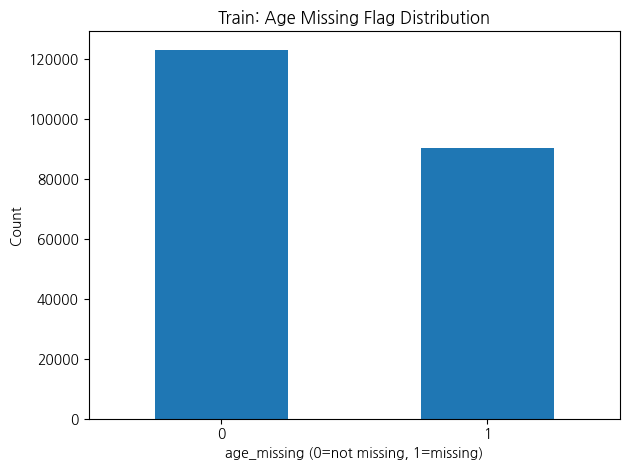

Missing ratio: 0.42347892490548183


In [22]:
counts = bnb_train_df['age_missing'].value_counts().sort_index()

plt.figure()
counts.plot(kind='bar')
plt.title("Train: Age Missing Flag Distribution")
plt.xlabel("age_missing (0=not missing, 1=missing)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Missing ratio:", bnb_train_df['age_missing'].mean())

<Figure size 640x480 with 0 Axes>

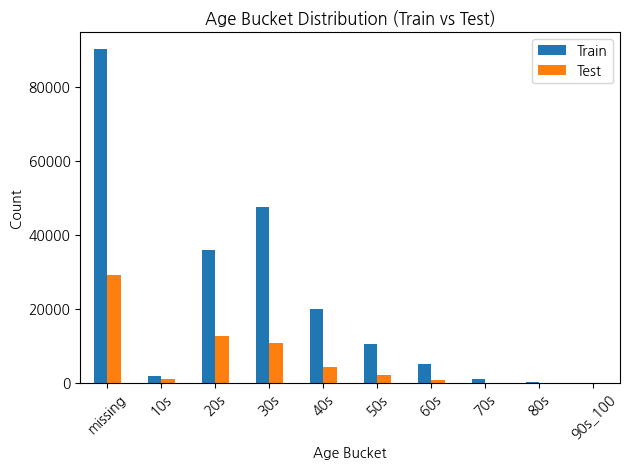

In [23]:
order = ['missing','10s','20s','30s','40s','50s','60s','70s','80s','90s_100']

train_bc = bnb_train_df['age_bucket'].value_counts().reindex(order, fill_value=0)
test_bc  = bnb_tst_df['age_bucket'].value_counts().reindex(order, fill_value=0)

age_bucket_df = pd.DataFrame({'Train': train_bc, 'Test': test_bc})

plt.figure()
age_bucket_df.plot(kind='bar')
plt.title("Age Bucket Distribution (Train vs Test)")
plt.xlabel("Age Bucket")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

→ 모델링을 LightGBM + CatBoost 모두 하기 위해서  
    `age` 결측치를 중앙값으로 대체하여 숫자형 컬럼으로 남겨 둠 (for LightGBM)  
    `age_bucket`, `age_missing` 범주형으로 컬럼 생성하여 남겨 둠 (for CatBoost)

---

### 2-2-3. 결측치 처리

user 파일의 결측치를 위에서 처리하였고, 남은 컬럼은 `first_affiliate_tracked` (처음 접한 마케팅 경로)  
범주형 컬럼이므로, 결측치를 'unknown'으로 대체

In [24]:
bnb_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213451 entries, 0 to 213450
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype    
---  ------                   --------------   -----    
 0   id                       213451 non-null  object   
 1   gender                   213451 non-null  object   
 2   age                      213451 non-null  float64  
 3   signup_method            213451 non-null  object   
 4   signup_flow              213451 non-null  int64    
 5   language                 213451 non-null  object   
 6   affiliate_channel        213451 non-null  object   
 7   affiliate_provider       213451 non-null  object   
 8   first_affiliate_tracked  207386 non-null  object   
 9   signup_app               213451 non-null  object   
 10  first_device_type        213451 non-null  object   
 11  first_browser            213451 non-null  object   
 12  country_destination      213451 non-null  object   
 13  dac_ym                   2134

In [25]:
for df in [bnb_train_df, bnb_tst_df]:
    df['first_affiliate_tracked'] = df['first_affiliate_tracked'].fillna('unknown')

---

### 2-2-4. 성별 컬럼 확인

- 현재, 성별 컬럼에 결측치는 없으나, '-unknown-'으로 기재되어 있음  
- 다른 전처리 컬럼과 동일하게 기호없는 'unknown'으로 대체  
(의미 없는 변화이나 일관성 유지를 위해)

In [26]:
for df in [bnb_train_df, bnb_tst_df]:
    df['gender'] = df['gender'].replace('-unknown-', 'unknown')

---

## 2-3. sessions 파일

- feature engineering

In [27]:
bnb_sessions_df

,user_id,action,action_type,action_detail,device_type,secs_elapsed
0,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,319.0
1,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,67753.0
2,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,301.0
3,d1mm9tcy42,search_results,click,view_search_results,Windows Desktop,22141.0
4,d1mm9tcy42,lookup,NaN,NaN,Windows Desktop,435.0
...,...,...,...,...,...,...
10567732,9uqfg8txu3,dashboard,view,dashboard,Windows Desktop,556.0
10567733,9uqfg8txu3,edit,view,edit_profile,Windows Desktop,6624.0
10567734,9uqfg8txu3,webcam_upload,-unknown-,-unknown-,Windows Desktop,200125.0
10567735,9uqfg8txu3,active,-unknown-,-unknown-,-unknown-,17624.0


### 2-3-1. 결측치 전처리

In [28]:
bnb_sessions_df.isna().sum()

user_id            34496
action             79626
action_type      1126204
action_detail    1126204
device_type            0
secs_elapsed      136031
dtype: int64

- `user_id`가 없으면 users 파일과 merge 할 수 없으므로 결측치 행 삭제 판단

In [29]:
bnb_sessions_df = bnb_sessions_df.dropna(subset=['user_id'])
bnb_sessions_df.isna().sum()

user_id                0
action             79480
action_type      1122957
action_detail    1122957
device_type            0
secs_elapsed      135483
dtype: int64

- `secs_elapsed` 머무는 시간(초)을 나타내므로, 해당 컬럼의 결측치는   
체류시간 없이 바로 나갔거나  
측정되지 않아 기록되지 않았음을 의미  
→ 결측치를 "머문 시간 없음"인 0으로 대체  

In [30]:
bnb_sessions_df['secs_elapsed'] = bnb_sessions_df['secs_elapsed'].fillna(0)
bnb_sessions_df.isna().sum()

user_id                0
action             79480
action_type      1122957
action_detail    1122957
device_type            0
secs_elapsed           0
dtype: int64

- `action` / `action_type `/ `action_detail` 대량 결측이지만 데이터 구조상 자연스러운 상황  
→ 결측치를 "unkonwn"으로 대체

In [31]:
for col in ['action', 'action_type', 'action_detail']:
    bnb_sessions_df[col] = bnb_sessions_df[col].fillna('unknown')
    bnb_sessions_df[col] = bnb_sessions_df[col].replace({'-unknown-': 'unknown'})

bnb_sessions_df.isna().sum()

user_id          0
action           0
action_type      0
action_detail    0
device_type      0
secs_elapsed     0
dtype: int64

---

### 2-3-2. 피처 엔지니어링

> - 총 세션 수
> - 체류시간 집계
> - action count pivot (상위 30개만)
> - 행동 다양성

- 총 세션 수  
id별 세션 수

In [32]:
session_count = (
    bnb_sessions_df
    .groupby('user_id')
    .size()
    .rename('session_count')
)

- 체류시간 집계

In [33]:
time_agg = (
    bnb_sessions_df
    .groupby('user_id')['secs_elapsed']
    .agg(['sum','mean','max'])
)

time_agg.columns = [
    'total_secs',
    'mean_secs',
    'max_secs'
]

- action count pivot (상위 30개만)

In [34]:
top_actions = (
    bnb_sessions_df['action']
    .value_counts()
    .head(30)
    .index
)

action_counts = (
    bnb_sessions_df[
        bnb_sessions_df['action'].isin(top_actions)
    ]
    .groupby(['user_id','action'])
    .size()
    .unstack(fill_value=0)
)

- 행동 다양성  
한 사용자가 서로 다른 action을 몇 종류 했는지 분류  
action 종류 : search, dashboard, personalize

In [35]:
diversity = (
    bnb_sessions_df
    .groupby('user_id')
    .agg(
        action_diversity=('action','nunique'),
        detail_diversity=('action_detail','nunique')
    )
)

In [36]:
session_features = pd.concat([
    session_count,
    time_agg,
    action_counts,
    diversity
], axis=1).fillna(0)

In [37]:
pd.set_option('display.max_columns', None)
session_features

,session_count,total_secs,mean_secs,max_secs,active,ajax_check_dates,ajax_refresh_subtotal,ask_question,campaigns,collections,confirm_email,create,dashboard,edit,header_userpic,identity,index,lookup,notifications,personalize,qt2,requested,reviews,search,search_results,show,show_personalize,similar_listings,similar_listings_v2,social_connections,track_page_view,unavailabilities,unknown,update,action_diversity,detail_diversity
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00023iyk9l,40,867896.0,21697.400000,567165.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,2.0,0.0,4.0,0.0,0.0,4.0,0.0,5.0,0.0,0.0,1.0,9.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,14,14
0010k6l0om,63,586543.0,9310.206349,127898.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,5.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,8.0,20.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,11,8
001wyh0pz8,90,282965.0,3144.055556,50548.0,4.0,0.0,0.0,0.0,3.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,66.0,0.0,6.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,10,9
0028jgx1x1,31,297010.0,9580.967742,84636.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,9.0,0.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,6
002qnbzfs5,789,6487080.0,8221.901141,1418284.0,29.0,0.0,0.0,0.0,28.0,0.0,1.0,21.0,2.0,0.0,2.0,2.0,115.0,0.0,9.0,0.0,0.0,0.0,13.0,125.0,0.0,232.0,0.0,0.0,0.0,72.0,0.0,21.0,7.0,13.0,26,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zzxox7jnrx,89,639436.0,7184.674157,98479.0,0.0,0.0,10.0,0.0,0.0,0.0,2.0,1.0,3.0,3.0,1.0,4.0,5.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0,12.0,11.0,2.0,0.0,10.0,0.0,2.0,0.0,0.0,1.0,28,18
zzy7t0y9cm,8,73771.0,9221.375000,42612.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,7
zzysuoqg6x,3,1731.0,577.000000,1533.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,3


- action pivot

In [38]:
action_count = (
    bnb_sessions_df
    .groupby(['user_id','action'])
    .size()
    .unstack(fill_value=0)
)

- entropy 추가

In [39]:
# 행동 비율
prob = action_count.div(action_count.sum(axis=1), axis=0)

# entropy 계산
entropy = -(prob * np.log(prob + 1e-9)).sum(axis=1)

# session_features에 추가
action_count['action_entropy'] = entropy

In [40]:
# 기존 session 집계와 병합
session_basic = (
    bnb_sessions_df
    .groupby('user_id')
    .agg({
        'secs_elapsed': ['count','sum','mean','max']
    })
)

session_basic.columns = ['session_count','total_secs','mean_secs','max_secs']

# entropy 포함한 action_count와 merge
session_features = session_basic.merge(
    action_count[['action_entropy']],
    left_index=True,
    right_index=True,
    how='left'
)

In [41]:
session_features

,session_count,total_secs,mean_secs,max_secs,action_entropy
user_id,,,,,
00023iyk9l,40,867896.0,21697.400000,567165.0,2.391068
0010k6l0om,63,586543.0,9310.206349,127898.0,1.986146
001wyh0pz8,90,282965.0,3144.055556,50548.0,1.117292
0028jgx1x1,31,297010.0,9580.967742,84636.0,1.226150
002qnbzfs5,789,6487080.0,8221.901141,1418284.0,2.350049
...,...,...,...,...,...
zzxox7jnrx,89,639436.0,7184.674157,98479.0,2.907670
zzy7t0y9cm,8,73771.0,9221.375000,42612.0,1.906155
zzysuoqg6x,3,1731.0,577.000000,1533.0,1.098612


---

## 2-4. age_gender_bkts 파일

### 2-4-1. Prior Feature 만들기

- 사전 확률 분포 만들기  
`age_bucket` + `gender` 조합별로 “어떤 나라를 얼마나 가는지” 확률

In [42]:
bnb_agb_df

,age_bucket,country_destination,gender,population_in_thousands,year
0,100+,au,male,1.0,2015.0
1,95-99,au,male,9.0,2015.0
2,90-94,au,male,47.0,2015.0
3,85-89,au,male,118.0,2015.0
4,80-84,au,male,199.0,2015.0
...,...,...,...,...,...
415,95-99,us,male,115.0,2015.0
416,90-94,us,male,541.0,2015.0
417,15-19,us,female,10570.0,2015.0
418,85-89,us,male,1441.0,2015.0


In [43]:
# user 파일과 동일하게 나이를 10단위로 구간화 처리하기
def agb_age_to_10s(age_bucket: str):
    if pd.isna(age_bucket):
        return np.nan
    s = str(age_bucket).strip().lower()

    # 100+ → 90s로 강제 통합 (user파일에 100+ 구간이 없기 때문에)
    if s.endswith('+'):
        try:
            start = int(s[:-1])
        except:
            return 'missing'
        if start >= 100:
            return '90s'
        return f"{(start//10)*10}s"

    # 15-19, 20-24 등
    if '-' in s:
        a = s.split('-')[0]
        try:
            start = int(a)
        except:
            return 'missing'
        if start >= 100:
            return '90s'
        return f"{(start//10)*10}s"

    # 단일 숫자
    try:
        start = int(s)
        if start >= 100:
            return '90s'
        return f"{(start//10)*10}s"
    except:
        return 'missing'

In [44]:
def build_age_gender_priors_10s(agb_df: pd.DataFrame, all_countries):
    g = agb_df.copy()

    # 문자열 정리 (너가 쓰던 normalize가 있으면 그걸 써도 됨)
    for c in ['age_bucket','gender','country_destination']:
        g[c] = g[c].astype(str).str.strip().str.lower()

    # population 컬럼 찾기
    pop_col = None
    for cand in ['population_in_thousands', 'population', 'count']:
        if cand in g.columns:
            pop_col = cand
            break
    if pop_col is None:
        raise ValueError("age_gender_bkts에서 population 컬럼을 찾지 못했습니다.")

    # 10단위 버킷 만들기
    g['age_bucket_10s'] = g['age_bucket'].apply(agb_age_to_10s)

    # groupby해서 확률 만들기
    pivot = (g.groupby(['age_bucket_10s', 'gender', 'country_destination'])[pop_col]
             .sum()
             .reset_index())

    total = pivot.groupby(['age_bucket_10s', 'gender'])[pop_col].transform('sum')
    pivot['prob'] = pivot[pop_col] / total

    wide = pivot.pivot_table(index=['age_bucket_10s', 'gender'],
                             columns='country_destination',
                             values='prob',
                             fill_value=0)

    # 누락 컬럼 보정
    for c in all_countries:
        if c not in wide.columns:
            wide[c] = 0.0
    wide = wide[all_countries]

    wide.columns = [f'agb_prior_{c}' for c in wide.columns]
    wide = wide.reset_index().rename(columns={'age_bucket_10s': 'age_bucket'})
    return wide

In [45]:
all_countries = sorted(bnb_agb_df['country_destination'].dropna().str.lower().unique())

wide_10s = build_age_gender_priors_10s(bnb_agb_df, all_countries)
print(wide_10s.shape)
wide_10s.head()

(20, 12)


,age_bucket,gender,agb_prior_au,agb_prior_ca,agb_prior_de,agb_prior_es,agb_prior_fr,agb_prior_gb,agb_prior_it,agb_prior_nl,agb_prior_pt,agb_prior_us
0,0s,female,0.036670,0.046883,0.081775,0.058466,0.092565,0.091339,0.066756,0.021339,0.011414,0.492791
1,0s,male,0.036839,0.047103,0.082293,0.059085,0.092259,0.091365,0.067378,0.021421,0.011524,0.490733
2,10s,female,0.034531,0.046345,0.090250,0.051438,0.091111,0.083052,0.066935,0.023364,0.012794,0.500179
3,10s,male,0.034518,0.046534,0.090647,0.051994,0.091401,0.083040,0.067643,0.023461,0.012839,0.497921
4,20s,female,0.035657,0.051787,0.101354,0.051940,0.086813,0.088794,0.068005,0.021964,0.012495,0.481192


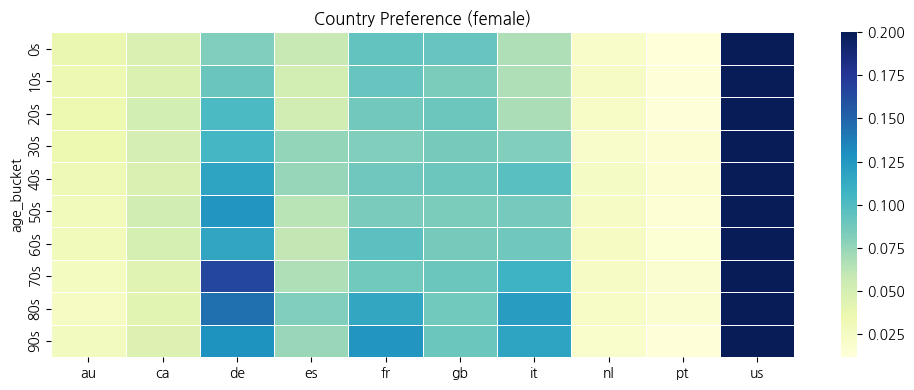

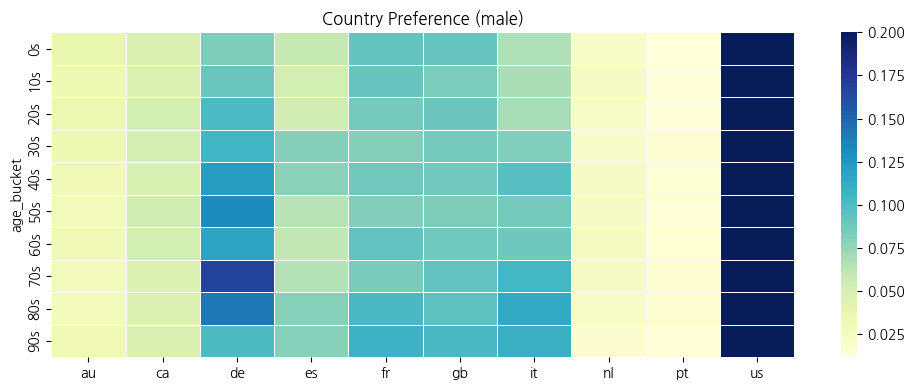

In [46]:
heat_df = wide_10s.copy()
prob_cols = [c for c in heat_df.columns if c.startswith('agb_prior_')]

for gender in ['female', 'male']:

    tmp = heat_df[heat_df['gender'] == gender].copy()
    tmp = tmp.sort_values('age_bucket')

    heat_data = tmp.set_index('age_bucket')[prob_cols]
    heat_data.columns = heat_data.columns.str.replace('agb_prior_', '')

    plt.figure(figsize=(10,4))
    sns.heatmap(heat_data,
                cmap='YlGnBu',
                vmax=0.2,
                linewidths=0.5)
    plt.title(f"Country Preference ({gender})")
    plt.tight_layout()
    plt.show()

---

# 3️⃣ 파일 병합

## 3-1. 타겟 변수(컬럼) 분리  

- train 파일 내 타겟 변수 `country_destination` 분리

In [47]:
y = bnb_train_df['country_destination']

bnb_train_df.drop(['country_destination'], axis=1, inplace=True)

In [48]:
bnb_train_df.columns

Index(['id', 'gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser',
       'dac_ym', 'dac_weekday', 'tfa_hour', 'dac_tfa_days', 'age_missing', 'age_bucket'],
      dtype='object')

In [49]:
bnb_tst_df.columns

Index(['id', 'gender', 'age', 'signup_method', 'signup_flow', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser',
       'dac_weekday', 'tfa_hour', 'dac_tfa_days', 'age_missing', 'age_bucket'],
      dtype='object')

## 3-2. merge

> - users + sessions + age_gender prior 병합<br>  
> - countries 파일은 모델 학습 후 예측 확률 나온 후 선택적으로 사용

In [50]:
# 병합 데이터 확인

print("sessions :")
display(session_features)
print("\ntest_users :")
display(bnb_tst_df)
print("\ntrain_users_2 :")
display(bnb_train_df)
print("\nage_gender_bkts :")
display(wide_10s)

sessions :


,session_count,total_secs,mean_secs,max_secs,action_entropy
user_id,,,,,
00023iyk9l,40,867896.0,21697.400000,567165.0,2.391068
0010k6l0om,63,586543.0,9310.206349,127898.0,1.986146
001wyh0pz8,90,282965.0,3144.055556,50548.0,1.117292
0028jgx1x1,31,297010.0,9580.967742,84636.0,1.226150
002qnbzfs5,789,6487080.0,8221.901141,1418284.0,2.350049
...,...,...,...,...,...
zzxox7jnrx,89,639436.0,7184.674157,98479.0,2.907670
zzy7t0y9cm,8,73771.0,9221.375000,42612.0,1.906155
zzysuoqg6x,3,1731.0,577.000000,1533.0,1.098612



test_users :


,id,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,dac_weekday,tfa_hour,dac_tfa_days,age_missing,age_bucket
0,5uwns89zht,female,35.0,facebook,0,en,direct,direct,untracked,moweb,iphone,mobile safari,1,0,0,0,30s
1,jtl0dijy2j,unknown,34.0,basic,0,en,direct,direct,untracked,moweb,iphone,mobile safari,1,0,0,1,missing
2,xx0ulgorjt,unknown,34.0,basic,0,en,direct,direct,linked,web,windows desktop,chrome,1,0,0,1,missing
3,6c6puo6ix0,unknown,34.0,basic,0,en,direct,direct,linked,web,windows desktop,ie,1,0,0,1,missing
4,czqhjk3yfe,unknown,34.0,basic,0,en,direct,direct,untracked,web,mac desktop,safari,1,0,0,1,missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62091,cv0na2lf5a,unknown,31.0,basic,0,en,direct,direct,untracked,web,windows desktop,ie,1,23,0,0,30s
62092,zp8xfonng8,unknown,34.0,basic,23,ko,direct,direct,untracked,android,android phone,-unknown-,1,23,0,1,missing
62093,fa6260ziny,unknown,34.0,basic,0,de,direct,direct,linked,web,windows desktop,firefox,1,23,0,1,missing
62094,87k0fy4ugm,unknown,34.0,basic,0,en,sem-brand,google,omg,web,mac desktop,safari,1,23,0,1,missing



train_users_2 :


,id,gender,age,signup_method,signup_flow,language,affiliate_channel,affiliate_provider,first_affiliate_tracked,signup_app,first_device_type,first_browser,dac_ym,dac_weekday,tfa_hour,dac_tfa_days,age_missing,age_bucket
0,gxn3p5htnn,unknown,34.0,facebook,0,en,direct,direct,untracked,web,mac desktop,chrome,2010-06,0,4,466,1,missing
1,820tgsjxq7,male,38.0,facebook,0,en,seo,google,untracked,web,mac desktop,chrome,2011-05,2,17,732,0,30s
2,4ft3gnwmtx,female,56.0,basic,3,en,direct,direct,untracked,web,windows desktop,ie,2010-09,1,23,476,0,50s
3,bjjt8pjhuk,female,42.0,facebook,0,en,direct,direct,untracked,web,mac desktop,firefox,2011-12,0,6,765,0,40s
4,87mebub9p4,unknown,41.0,basic,0,en,direct,direct,untracked,web,mac desktop,chrome,2010-09,1,6,280,0,40s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213446,zxodksqpep,male,32.0,basic,0,en,sem-brand,google,omg,web,mac desktop,safari,2014-06,0,23,0,0,30s
213447,mhewnxesx9,unknown,34.0,basic,0,en,direct,direct,linked,web,windows desktop,chrome,2014-06,0,23,0,1,missing
213448,6o3arsjbb4,unknown,32.0,basic,0,en,direct,direct,untracked,web,mac desktop,firefox,2014-06,0,23,0,0,30s
213449,jh95kwisub,unknown,34.0,basic,25,en,other,other,tracked-other,ios,iphone,mobile safari,2014-06,0,23,0,1,missing



age_gender_bkts :


,age_bucket,gender,agb_prior_au,agb_prior_ca,agb_prior_de,agb_prior_es,agb_prior_fr,agb_prior_gb,agb_prior_it,agb_prior_nl,agb_prior_pt,agb_prior_us
0,0s,female,0.036670,0.046883,0.081775,0.058466,0.092565,0.091339,0.066756,0.021339,0.011414,0.492791
1,0s,male,0.036839,0.047103,0.082293,0.059085,0.092259,0.091365,0.067378,0.021421,0.011524,0.490733
2,10s,female,0.034531,0.046345,0.090250,0.051438,0.091111,0.083052,0.066935,0.023364,0.012794,0.500179
3,10s,male,0.034518,0.046534,0.090647,0.051994,0.091401,0.083040,0.067643,0.023461,0.012839,0.497921
4,20s,female,0.035657,0.051787,0.101354,0.051940,0.086813,0.088794,0.068005,0.021964,0.012495,0.481192
5,20s,male,0.035829,0.051728,0.101513,0.052689,0.086095,0.089291,0.068399,0.021832,0.012410,0.480216
6,30s,female,0.035059,0.051178,0.104651,0.076010,0.082113,0.085774,0.081671,0.020770,0.016330,0.446444
7,30s,male,0.034855,0.050912,0.105417,0.080283,0.080533,0.086598,0.081654,0.020626,0.016410,0.442711
8,40s,female,0.032267,0.047204,0.117040,0.074703,0.088057,0.088947,0.096761,0.024136,0.016084,0.414802
9,40s,male,0.031652,0.047755,0.121972,0.078456,0.087270,0.087191,0.097134,0.024402,0.015885,0.408283


- users + sessions 병합 (users ← sessions)  

In [51]:
X_train = bnb_train_df.copy()
X_test  = bnb_tst_df.copy()

# 1) key 타입 통일
X_train['id'] = X_train['id'].astype(str)
X_test['id']   = X_test['id'].astype(str)
session_features.index = session_features.index.astype(str)

# 2) merge
X_train = X_train.merge(
    session_features,
    left_on='id',
    right_index=True,
    how='left'
)

X_test = X_test.merge(
    session_features,
    left_on='id',
    right_index=True,
    how='left'
)

# 3) 세션 없는 유저 → 0
sess_cols = session_features.columns
X_train[sess_cols] = X_train[sess_cols].fillna(0)
X_test[sess_cols]   = X_test[sess_cols].fillna(0)

print("train shape after sessions:", X_train.shape)
print("test  shape after sessions:", X_test.shape)

train shape after sessions: (213451, 23)
test  shape after sessions: (62096, 22)


- users + age_gender prior 병합 (users ← wide_10s)

In [52]:
# 1) key 정규화(소문자/공백)
for df in [X_train, X_test]:
    df['age_bucket'] = df['age_bucket'].astype(str).str.strip().str.lower()
    df['gender'] = df['gender'].astype(str).str.strip().str.lower().replace({'-unknown-':'unknown'})

wide_10s = wide_10s.copy()
wide_10s['age_bucket'] = wide_10s['age_bucket'].astype(str).str.strip().str.lower()
wide_10s['gender'] = wide_10s['gender'].astype(str).str.strip().str.lower().replace({'-unknown-':'unknown'})

# 2) merge
X_train = X_train.merge(
    wide_10s,
    on=['age_bucket', 'gender'],
    how='left'
)

X_test = X_test.merge(
    wide_10s,
    on=['age_bucket', 'gender'],
    how='left'
)

prior_cols = [c for c in X_train.columns if c.startswith('agb_prior_')]
global_prior = y.value_counts(normalize=True)

for col in prior_cols:
    k = col.replace('agb_prior_', '')  # e.g. 'us'
    fill_value = global_prior.get(k, 0.0)
    X_train[col] = X_train[col].fillna(fill_value)
    X_test[col]  = X_test[col].fillna(fill_value)

print("train shape after priors:", X_train.shape)
print("test  shape after priors:", X_test.shape)
print("prior missing rate train:", X_train[prior_cols].isna().mean().mean())
print("prior missing rate test :", X_test[prior_cols].isna().mean().mean())

train shape after priors: (213451, 33)
test  shape after priors: (62096, 32)
prior missing rate train: 0.0
prior missing rate test : 0.0


---

# 4️⃣ EDA

## 4-1. user 파일 컬럼별 관계

### 4-1-1. 수치형 변수 분포 비교 (age, signup_flow 등)

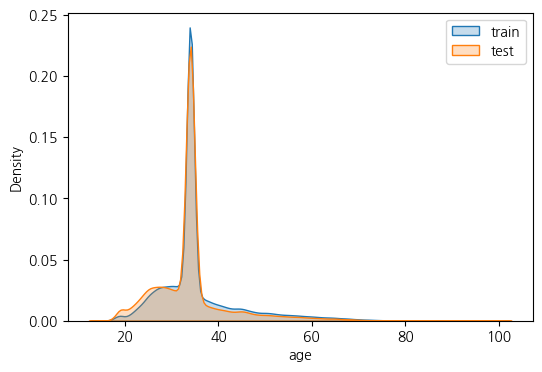

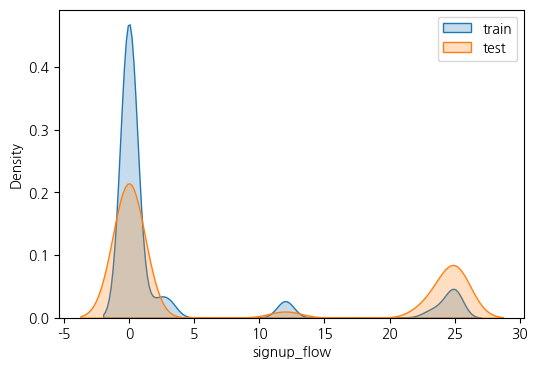

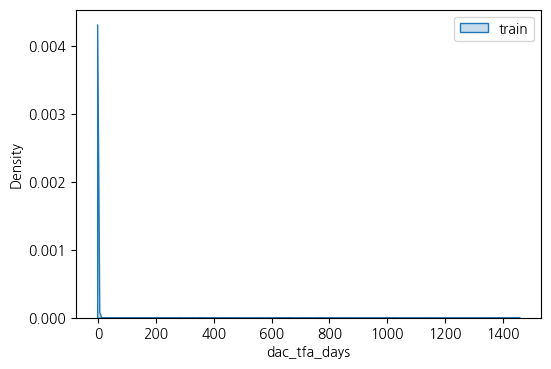

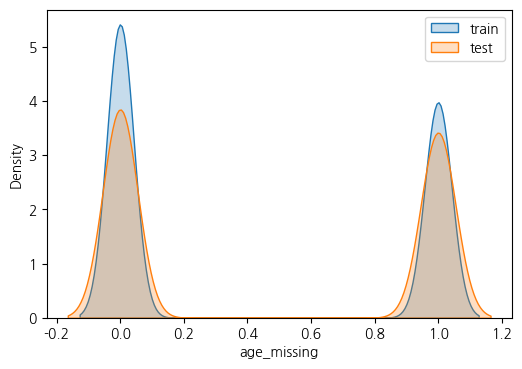

In [53]:
num_cols = bnb_train_df.select_dtypes(include=['int64','float64']).columns

valid_cols = [c for c in num_cols if c in bnb_train_df.columns and c in bnb_tst_df.columns]

for col in valid_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(bnb_train_df[col], label='train', fill=True)
    sns.kdeplot(bnb_tst_df[col], label='test', fill=True)
    plt.legend()
    plt.show()

- `age`  
train/test 거의 동일  
30~40대에 큰 피크  
오른쪽 꼬리 약간 존재  
→ 좋은 feature  
<br>
- `signup_flow`  
train은 0 근처에 강한 피크  
test는 20~25 근처에 추가 피크  
분포 형태가 다름  
→ train/test 데이터 수집 시점 차이가 있어 가입 플로우가 변경됨을 확인  
→ 이 변수는 모델 성능 흔들 가능성 있음  
<br>
- `dac_tfa_days`  
대부분 0 근처  
매우 긴 오른쪽 꼬리 (1400일까지 존재)  
극단적 skew (이상치 영향 매우 큼)  
→ train/test 비교가 시각적으로 어렵지만, 이런 변수는 그대로 쓰면 모델 불안정 가능성 있음  
<br>
- `age_missing`  
0 / 1 이진 변수  
train/test 비율 거의 비슷  
→ 모델 사용에 문제 없는 변수  
<br>
👉 로지스틱 회귀, LightGFM일 경우 OneHot(범주형으로 변환)하여 사용  
👉 CatBoost일 경우 그대로 사용

---

### 4-1-2. 수치형 변수 상관관계 (히트맵)

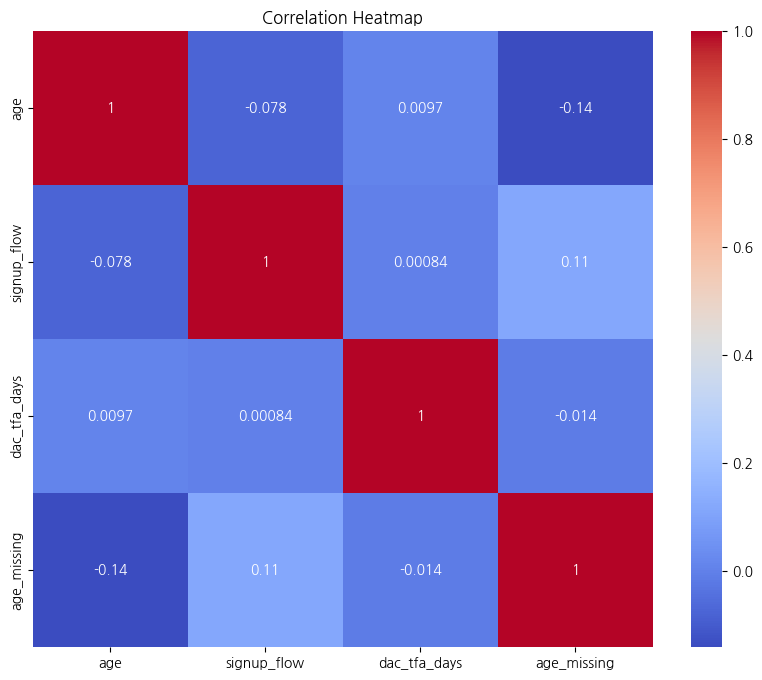

In [54]:
corr = bnb_train_df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

- 모든 상관계수가 |0.15| 이하 : 강한 선형 상관관계는 전혀 없음  

- `age` ↔ `signup_flow` (-0.078)  
: 나이와 가입 플로우는 거의 무관  

- `age` ↔ `age_missing` (-0.14)  
: 약한 음의 상관  
: 나이가 높을수록 missing이 약간 적은 경향  
: 하지만 매우 약한 값으로 실질 영향 거의 없는 것으로 확인  

- `signup_flow` ↔ `age_missing` (0.11)  
: 약한 양의 상관  
: 특정 가입 경로에서 나이 미입력 비율이 약간 높을 수 있음  
: 하지만 매우 약한 값  

- `dac_tfa_days` ↔ 다른 변수들 (~0)  
: 거의 완전 독립 수준  
: 이 변수는 다른 변수들과 선형적으로 묶이지 않았았므로, 독립 정보 제공 가능성 있음  

---

### 4-1-3. 범주형 변수

- Age vs Country  
    - 대부분 국가의 중앙값이 30~35세 근처 / IQR(박스 범위)도 거의 비슷 / 전반적으로 큰 차이는 없음  
    - 즉, 나이 하나만으로 국가를 강하게 구분하긴 어려움  
    - 단독 강한 변수는 아님 / 상호작용에서 가치 있을 가능성 있음

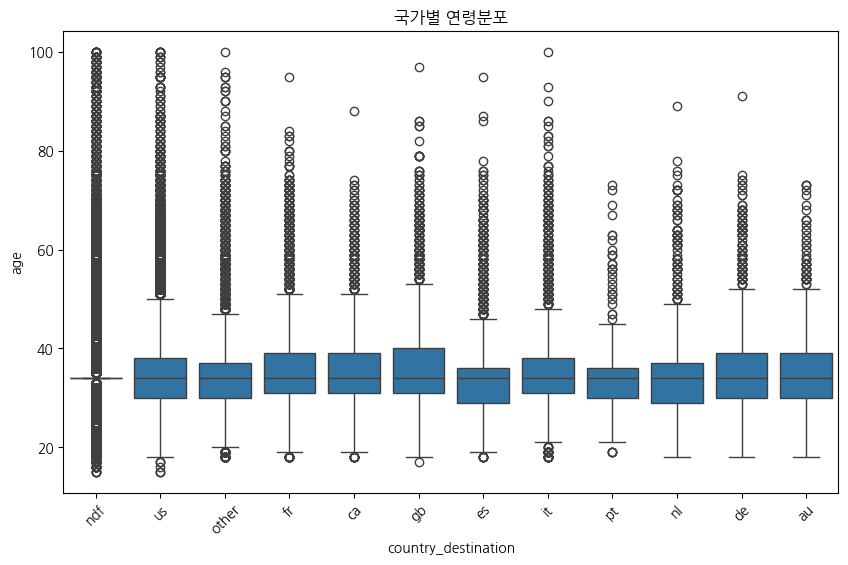

In [55]:
tmp = X_train.copy()
tmp['country_destination'] = y

tmp = pd.concat(
    [X_train.reset_index(drop=True),
     y.reset_index(drop=True)],
    axis=1
)

y.unique()

plt.figure(figsize=(10,6))
sns.boxplot(x='country_destination', y='age', data=tmp)
plt.xticks(rotation=45)
plt.title("국가별 연령분포")
plt.show()

- Age vs Country  
    - 여성 : ndf 49% / us 36% / other 5% / 유럽 국가들은 1~3%대  
    <br>  
    - 남성 : ndf 49% / us 36% / other 6.3%  
    → 남녀 차이 거의 없음  
    <br>  
    - other : ndf 38% (낮음) / us 41% (높음) / other 7.8% (상대적으로 높음)  
    → “other” 그룹은 ndf보다 us 비율이 더 높음  
    → 표본 수가 적을 가능성 매우 높으므로, 통계적 해석 조심해야 함  
    <br>  
    - unknown : ndf 70% (매우 높음) / us 21% (낮음)  
    → 성별 미입력자는 국가 선택 안 한 비율이 매우 높음 (강한 행동 신호)  

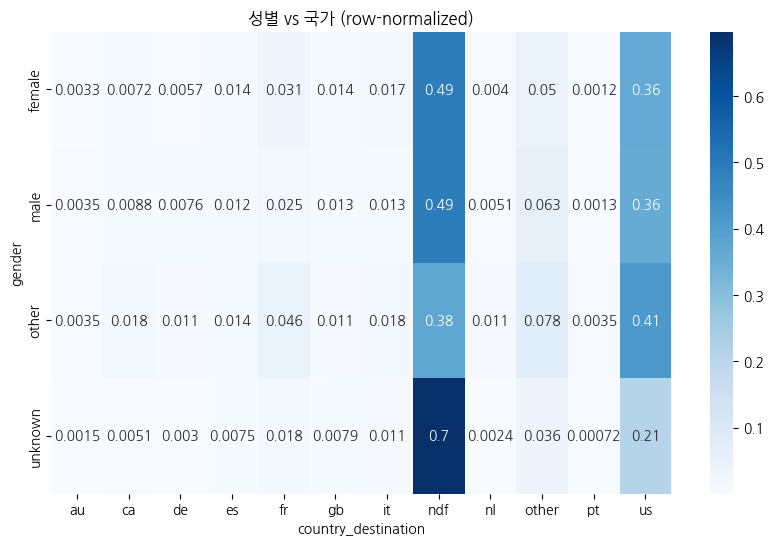

In [56]:
# 행(row)이 1로 정규화되어 있음
ct = pd.crosstab(tmp['gender'],
                 tmp['country_destination'],
                 normalize='index')

plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, cmap='Blues')
plt.title("성별 vs 국가 (row-normalized)")
plt.show()

- Language vs Country : 이 언어 사용자가 어떤 국가를 선택했는가의 비율 (각 행 합이 1)  
    - 거의 모든 언어에서 NDF 비율이 가장 큼  
    → 전체 사용자 중 예약을 하지 않는 비율이 매우 높음을 확인  
    <br>  
    - 예약한 사용자 기준에서는 거의 모든 언어에서 US가 가장 높음  
    <br>  
    - 일부 언어에서는 모국어 국가 선택 비율이 상대적으로 높아지는 경향이 존재  
    <br>  
    - language는 예약 여부(NDF) 예측에 매우 강한 설명력을 가지며,  
    예약 국가 예측에도 의미 있는 변수임을 확인  

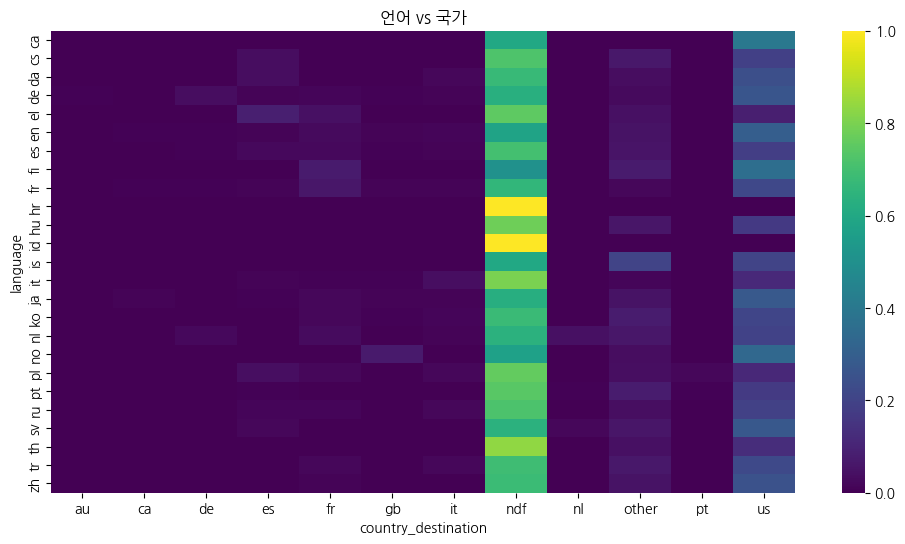

In [57]:
# 행(row)이 1로 정규화되어 있음
ct = pd.crosstab(tmp['language'],
                 tmp['country_destination'],
                 normalize='index')

plt.figure(figsize=(12,6))
sns.heatmap(ct, cmap='viridis')
plt.title("언어 vs 국가")
plt.show()

---

### 4-1-4. 시간 변수와 국가 관계

각 월마다 국가 선택 비율이 어떻게 변했는지 확인 (각 월 합 = 1)

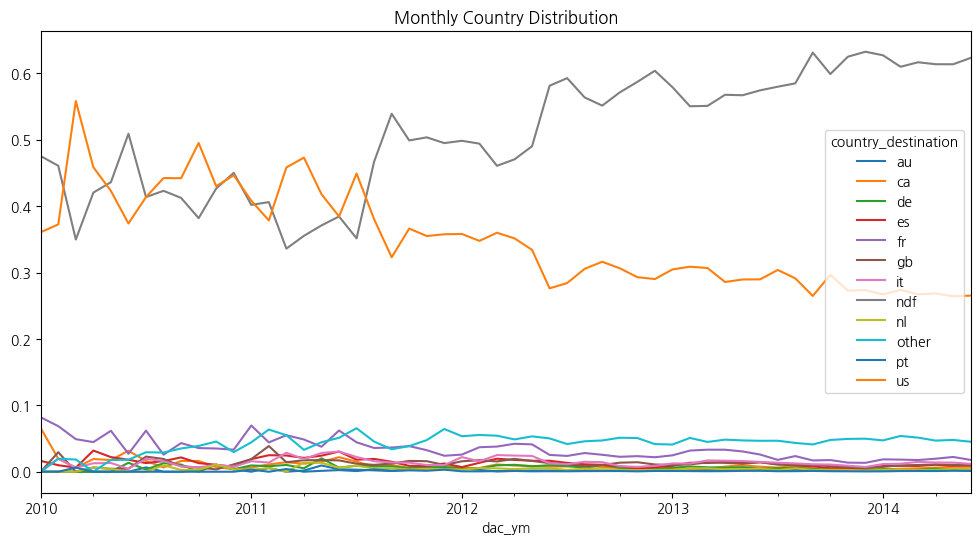

In [58]:
# 행(row)이 1로 정규화되어 있음
monthly = pd.crosstab(tmp['dac_ym'], 
                      tmp['country_destination'], 
                      normalize='index')

monthly.plot(figsize=(12,6))
plt.title("Monthly Country Distribution")
plt.show()

- NDF 비율이 시간이 갈수록 증가  
→ 시간이 갈수록 예약을 하지 않는 사용자 비율이 증가  

- US 비율은 점진적으로 감소 (상대 비율 감소)  

- Other 국가 비율 점진적으로 상승  
→ 시장 다양화 가능성  

👉 시간이 지날수록 예약 전환율이 낮아지고 있음을 의미  
👉 시간에 따라 타겟 분포가 변하는 문제로, 타겟 분포에 명확한 시간적 변화가 존재함을 확인  

---

### 4-1-5. 기기와 국가 관계 : 기기와 국가 관계

각 기기(행) 사용자 중에서 실제로 예약한 사람들은 어느 국가를 선택했는가의 비율  
(각 행 합 = 1)  

cf. NDF 포함 시 예약 여부가 지배적인 구조가 되므로, NDF를 제외하여 어디를 선택했는지를 더 명확하게 확인  

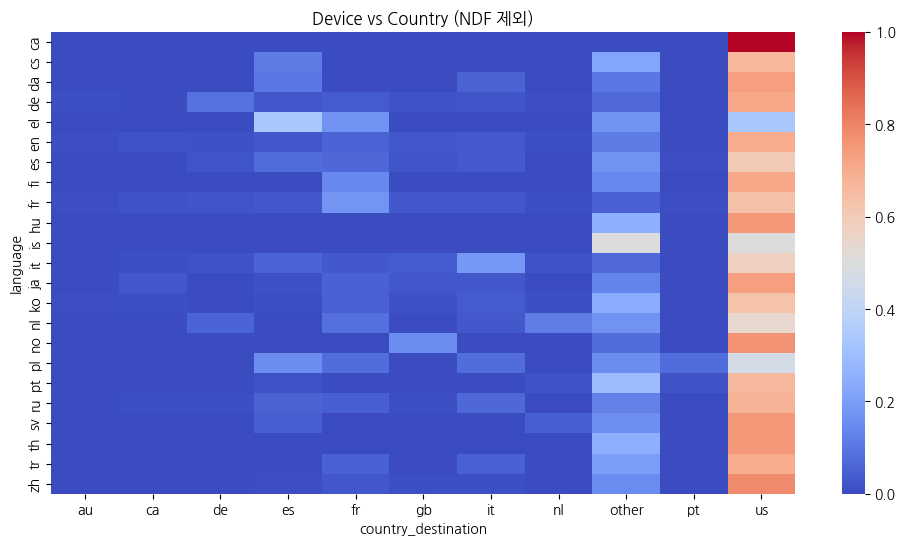

In [59]:
tmp_no_ndf = tmp[tmp['country_destination'].str.upper() != 'NDF']

# 행(row)이 1로 정규화되어 있음
ct = pd.crosstab(tmp_no_ndf['language'],
                 tmp_no_ndf['country_destination'],
                 normalize='index')

plt.figure(figsize=(12,6))
sns.heatmap(ct, cmap='coolwarm')
plt.title("Device vs Country (NDF 제외)")
plt.show()

- 거의 모든 기기에서 US 비율이 가장 높음  
    - 기기 차이보다 국가 선호 구조가 더 강함  
<br>  
- other가 두 번째로 높은 경우 많음  
    - 비미국권 분산 선택 존재  
<br>  
- 특정 기기에서 일부 국가 비율 상승  
    - 몇몇 기기에서 ES, FR, NL 등 특정 국가 비율이 상대적으로 높음  
    - 하지만 전반적으로는 차이가 크지 않음  

👉 기기는 “강한 분리 변수”는 아님  
👉 국가 선택 패턴은 기기보다 더 상위 요인에 의해 결정  
(예상 상위 요인 : 언어, 사용자 국가, 확률분포, 세션 행동 데이터 등)

---

### 4-1-6. 유입 경로 vs 국가

각 유입 경로(행)에서 실제 예약한 사용자들은 어느 국가를 선택했는가의 비율  
(각 행 합 = 1)  

cf. NDF 포함 시 대부분의 채널에서 NDF 비율이 매우 커서 "예약 여부" 구조가 지배하므로,  
NDF를 제외하여 실제 예약한 사람만 기준으로 확인  

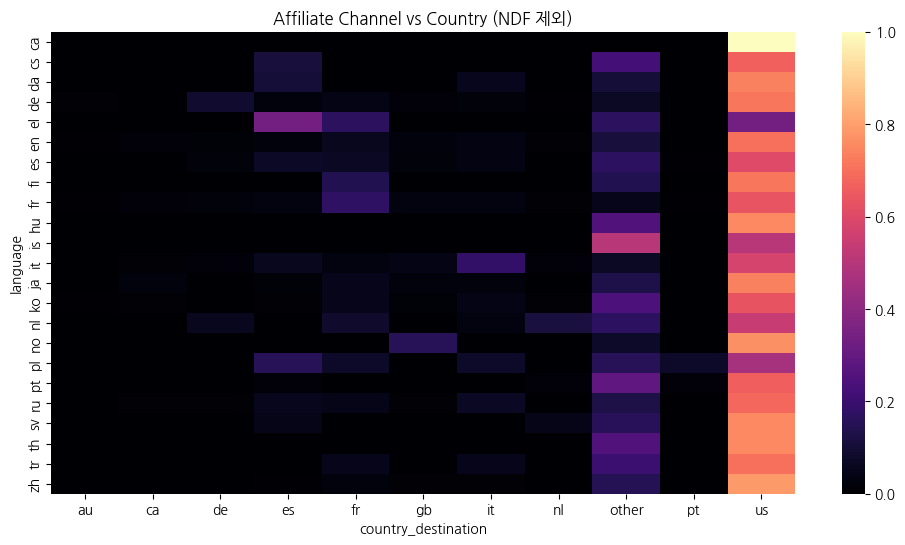

In [60]:
# 행(row)이 1로 정규화되어 있음
ct = pd.crosstab(tmp_no_ndf['language'],
                 tmp_no_ndf['country_destination'],
                 normalize='index')

plt.figure(figsize=(12,6))
sns.heatmap(ct, cmap='magma')
plt.title("Affiliate Channel vs Country (NDF 제외)")
plt.show()

- 거의 모든 유입 채널에서 US가 가장 높음  
→ 유입 경로보다 국가 선호 구조(US dominance)가 훨씬 강함  
<br>  
- Other가 두 번째로 높은 경우 많음  
    - 비미국권 선택은 분산된 형태  
<br>  
- 일부 채널에서 특정 국가 비율 상승  
    - 특정 채널에서 ES 또는 FR가 상대적으로 조금 높으나, 극단적인 차이는 아님  
    - 채널별로 약간의 차이는 있지만, 전반적인 국가 선택 구조를 바꾸지는 않음  

👉 유입 경로는 “강한 국가 분리 변수”는 아님  
👉 유입 경로보다 상위 요인이 더 중요  
(국가 선택을 더 잘 설명하는 변수들: 언어, agb_prior_*, session 행동 변수, 사용자 국가 관련 변수)

---

## 4-2. sessions 파일 컬럼별 관계

### 4-2-1. PCA 행동 패턴

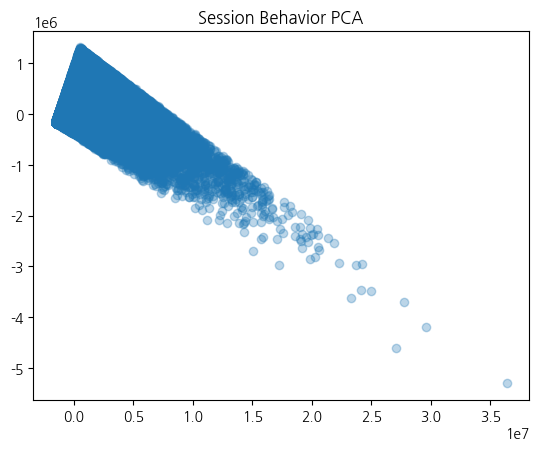

In [61]:
from sklearn.decomposition import PCA

X = session_features.fillna(0)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.3)
plt.title("Session Behavior PCA")
plt.show()

- 거의 하나의 대각선 방향으로 길게 퍼진 형태  
    - 클러스터가 여러 개로 나뉘지 않음 (삼각형/부채꼴 형태)  
    - “완전 다른 행동 그룹”이 존재한다기보다는 행동 강도의 연속적인 스케일 차이  
<br>  
- PC1이 거의 전체 분산을 설명하는 구조  
    - PC1이 압도적으로 큰 축 / PC2는 보조적 역할 (거의 1차원 구조)  
    - session feature들이 대부분 같은 방향으로 움직이고 있음  
<br>  
- 오른쪽 아래 튀는 점들 (아웃라이어)  
    - PC1 매우 큼 / PC2 매우 낮음  
    - 세션 수, 체류시간 등이 극단적으로 큰 사용자일 가능성  

👉 "활동량(activity level)"이라는 하나의 공통 요인이 존재  
👉 세션 행동은 유형(cluster)보다는 활동량(activity intensity) 스케일 차이 구조에 가까움  

---

### 4-2-2. 행동 강도 vs 예약 확률

행동 강도(session_count)가 예약 여부에 얼마나 영향을 주는지 보는 그래프  

- x축: log(1 + session_count)  
- y축: 밀도 (확률 아님, 분포 형태)  
<br>  
- 파란색: 예약 안 함 (0, NDF)  
- 주황색: 예약함 (1)

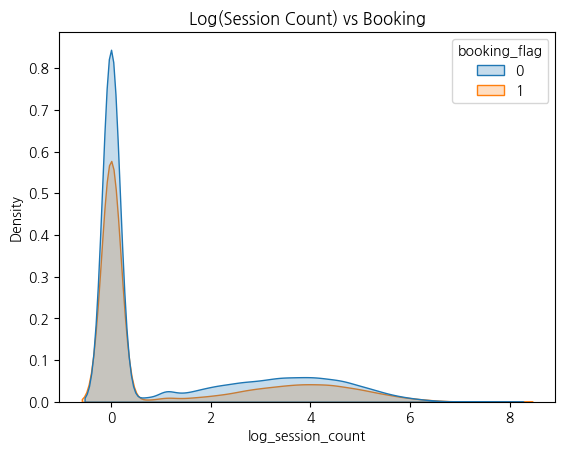

In [62]:
# 로그 변환해서 봄
tmp_s = X_train.copy()
tmp['booking_flag'] = (y.str.upper() != 'NDF').astype(int)

tmp['log_session_count'] = np.log1p(tmp['session_count'])

sns.kdeplot(data=tmp, x='log_session_count', hue='booking_flag', fill=True)
plt.title("Log(Session Count) vs Booking")
plt.show()

- 0 근처에 큰 봉우리  
    - session_count가 거의 0~1 수준  
    - 예약 안 한 사람이 훨씬 많음 → 거의 방문만 하고 떠난 사용자  
<br>  
- 오른쪽으로 갈수록 (활동량 증가)  
    - 예약한 사람(주황)이 상대적으로 더 많아짐  
    - 활동이 많아질수록 예약 확률 상승  
<br>  
- 하지만 완전히 분리되진 않음 (두 분포가 상당히 겹쳐 있음)  
    - session_count 하나만으로 예약을 완벽히 구분하긴 어려움  
    - 하지만 방향성은 명확함  

👉 세션 수가 많을수록 예약 확률이 증가하는 경향  
👉 행동 강도는 예약 예측에 유의미한 설명 변수  

---

## 4-3. age_gender_bkts 파일 컬럼별 관계

- 확률 컬럼만 분리

In [63]:
heat_df = wide_10s.copy()
prob_cols = [c for c in heat_df.columns if c.startswith('agb_prior_')]

### 4-3-1. 국가 간 상관관계 (Country vs Country)

age_gender_bkts 기반 국가 prior 확률들 간의 상관관계  
특정 연령·성별 그룹에서 어떤 국가 확률이 같이 높아지는지 / 반대로 움직이는지 보는 것

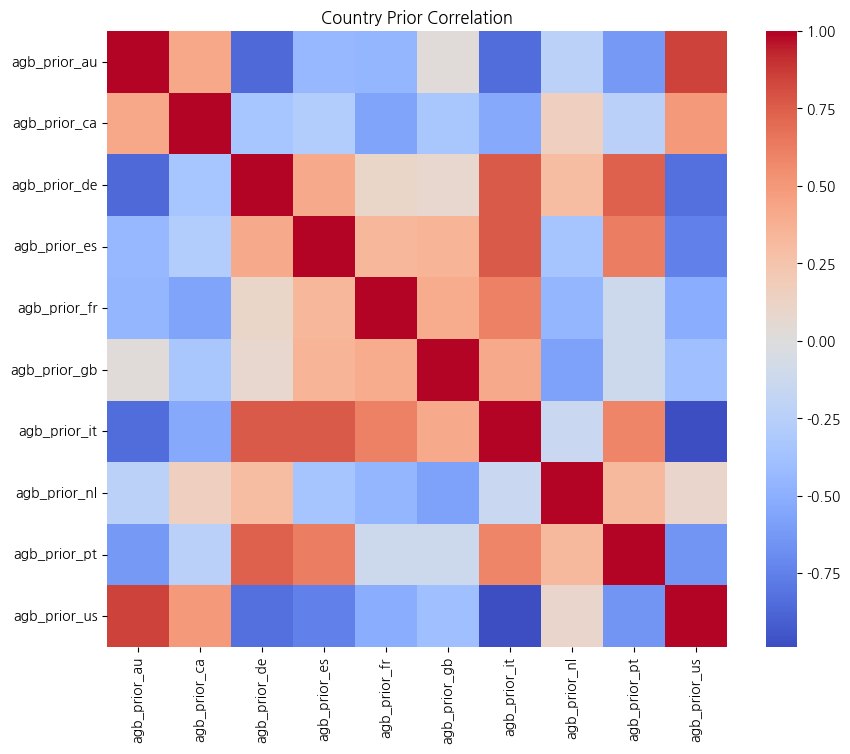

In [64]:
corr_df = heat_df[prob_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_df, cmap='coolwarm', center=0)
plt.title("Country Prior Correlation")
plt.show()

- `US` ↔ `AU`, `CA` 강한 양의 상관  
    - `agb_prior_us` ↔ `au`, `ca`  
    - 특정 연령·성별 그룹에서 미국 확률이 높으면 AU/CA도 함께 높아짐  
    - 영어권 국가에 대한 선호 인구 통계학 패턴이 유사함을 시사    
<br>  
- `DE`, `ES`, `FR`, `IT`, `PT`끼리 강한 양의 상관  
    - 특정 인구 통계학 그룹이 유럽권 국가 전반에 대해 비슷한 확률 구조를 가짐  
    - 유럽권 인구 통계학 선호 패턴 존재  
<br>  
- US ↔ 유럽 일부 국가 강한 음의 상관  
    - 영어권 성향이 강한 그룹은 유럽권 확률이 낮은 구조  
    - 인구 통계학 선호 축이 분리됨  
<br>  
- NL은 중립적 위치  
    - 특정 블록에 강하게 속하지 않음  
    - 중립적 위치  

👉 이 변수들은 선형 결합 관계에 가까워 강한 다중공선성을 형성함  
👉 선형 모델(로지스틱)에는 문제가 될 수 있고, 트리 모델(LightGBM)에는 성능 저하는 크지 않으나 상관된 변수들 간 분할이 분산되어 feature importance 해석이 왜곡될 수 있으므로, 반드시 처리 후 진행  


> 선형 모델을 쓸 경우 (Logistic, Linear) 처리 방법 
> 1) 기준 하나 제거  
> 2) PCA로 축소  
> 3) 블록 합성  

> LightGBM / 트리 모델 쓸 경우  
> - Top 중요도 몇 개만 남기거나  
> - PCA 3~4개 축으로 대체  


---

### 4-3-2. 연령대별 국가 분포 (gender 통합)

연령대가 바뀌면 어떤 국가 선호 확률이 어떻게 달라지는가  

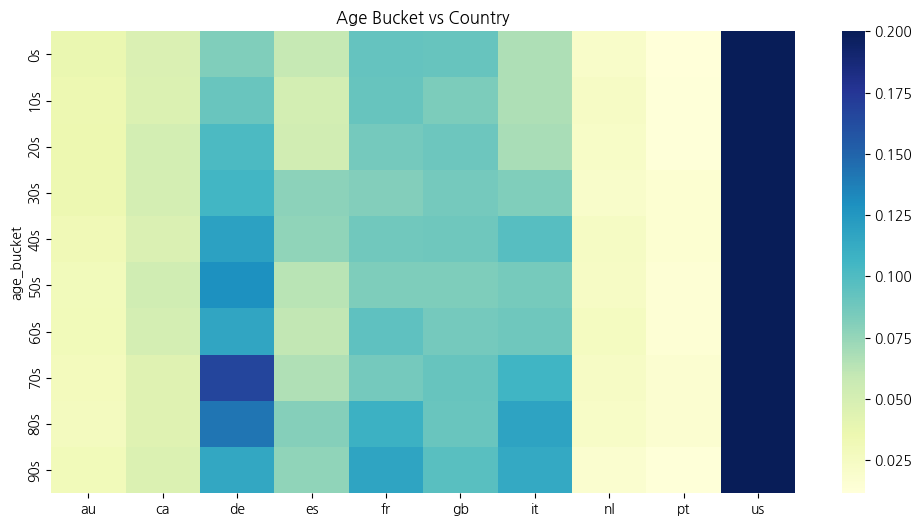

In [65]:
tmp = heat_df.copy()
tmp_group = tmp.groupby('age_bucket')[prob_cols].mean()

tmp_group.columns = tmp_group.columns.str.replace('agb_prior_', '')

plt.figure(figsize=(12,6))
sns.heatmap(tmp_group, cmap='YlGnBu', vmax=0.2)
plt.title("Age Bucket vs Country")
plt.show()

- US가 모든 연령대에서 가장 높음  
    - 기본 수요 구조가 “US 중심”임  
<br>   
- 연령에 따른 변화 패턴  
    - DE (독일)  
    40대 이후부터 점점 진해짐  
    특히 70~80대에서 매우 높음  
    고연령층에서 독일 선호가 상대적으로 높음  
<br>  
    - FR / IT  
    연령 증가에 따라 점진적으로 상승  
    특히 60대 이후에서 상승  
    중·고령층에서 유럽 대륙 국가 비중 증가  
<br>  
    - GB  
    중년층(30~50대)에서 상대적으로 높음  
    이후 완만  
<br>  
    - AU / CA  
    전 연령대에서 낮고 큰 변화 없음  
    구조적으로 안정적  
<br>  
    - NL / PT  
    거의 연령 영향 없음  
    낮은 수준 유지  

<br> 
 
- 연령 효과는 존재하지만 “급격하지 않음”   
→ 고연령층일수록 유럽 대륙 국가 비율이 증가하는 경향 존재  
<br>  
- 연령은 “미세 조정 변수”  
→ 국가 선택을 결정하는 핵심 변수라기보다는 특정 국가의 확률을 조금씩 올리고 내리는 역할  
<br>  
- US dominance는 연령과 무관  
→ 연령과 상관없이 항상 가장 높음 (구조적 시장 특성)  

👉 연령은 국가 선택에 약한 구조적 영향이 있으며, 특히 고연령층에서 유럽 대륙 국가 확률이 증가하는 경향  
👉 그러나 전체 구조는 여전히 US 중심

---

### 4-3-3. 성별별 국가 평균 비교

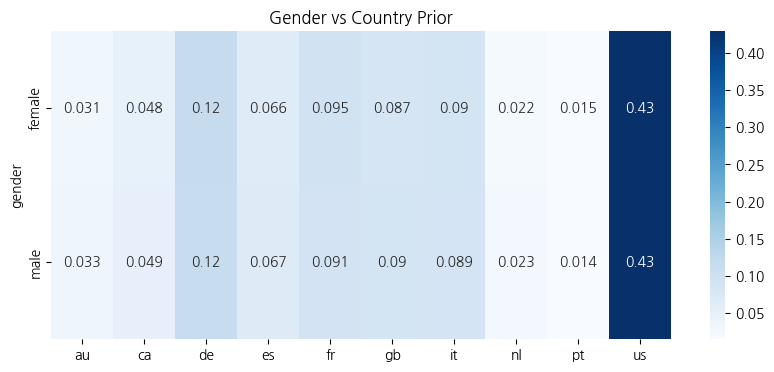

In [66]:
gender_group = heat_df.groupby('gender')[prob_cols].mean()
gender_group.columns = gender_group.columns.str.replace('agb_prior_', '')

plt.figure(figsize=(10,4))
sns.heatmap(gender_group, annot=True, cmap='Blues')
plt.title("Gender vs Country Prior")
plt.show()

- US  
    - female: 0.43  
    - male: 0.43  
    - 완전히 동일
<br>  
- DE  
    - female: 0.12  
    - male: 0.12  
    - 차이 거의 없음  
<br>  
- FR / GB / IT 등  
    - 차이 최대 0.003~0.005 수준  
    - 실질적으로 거의 동일  
<br>  
- AU / CA / NL / PT  
    - 차이 0.001~0.002 수준  
    - 통계적 의미도 거의 없을 가능성  

👉 성별에 따른 국가 선호 차이는 매우 작음 (gender는 국가 선택을 강하게 설명하는 변수는 아님)  
👉 연령은 고연령층에서 유럽 상승 경향이 있었지만 성별은 거의 차이가 없음  

---

### 4-3-4. 특정 국가의 연령 패턴 보기 (Line Plot)

US 선택 확률(agb_prior_us)이 연령대별로 어떻게 변하는지, 그리고 성별 차이가 있는지 확인

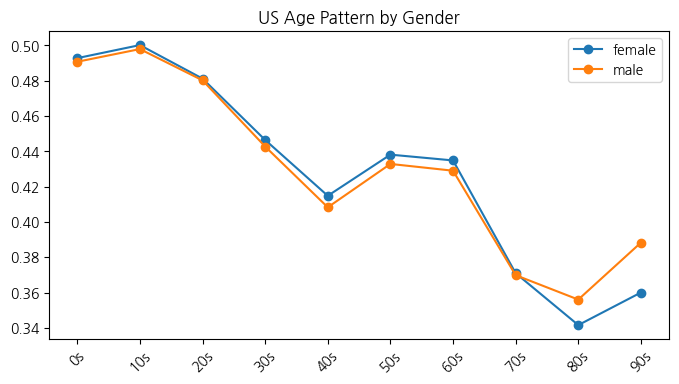

In [67]:
country = 'us'  # 원하는 국가 코드

col_name = f'agb_prior_{country}'
tmp = heat_df.copy()

plt.figure(figsize=(8,4))
for g in ['female','male']:
    sub = tmp[tmp['gender']==g].sort_values('age_bucket')
    plt.plot(sub['age_bucket'], sub[col_name], marker='o', label=g)

plt.xticks(rotation=45)
plt.legend()
plt.title(f"{country.upper()} Age Pattern by Gender")
plt.show()

- 연령이 증가할수록 US 확률이 전반적으로 감소  
젊은 층일수록 US 확률이 높고, 고령층일수록 낮아지는 구조  
<br>  
- 성별 차이는 매우 작음  
<br>  
- 50~60대에서 소폭 반등  
완전 단조 감소는 아니고 약간의 굴곡 존재  

👉 연령이 증가할수록 US 선택 확률은 감소하는 경향이 있으며, 성별 차이는 거의 없다.

---

### 4-3-5. PCA로 국가 패턴 구조 보기

age_bucket × gender 단위의 국가 prior 벡터(10개 국가 확률)를 PCA로 2차원에 축소한 것  

- 각 점 = 하나의 (연령대 × 성별) 그룹  
- 위치 = 그 그룹의 “국가 선택 확률 패턴”의 구조적 유사성

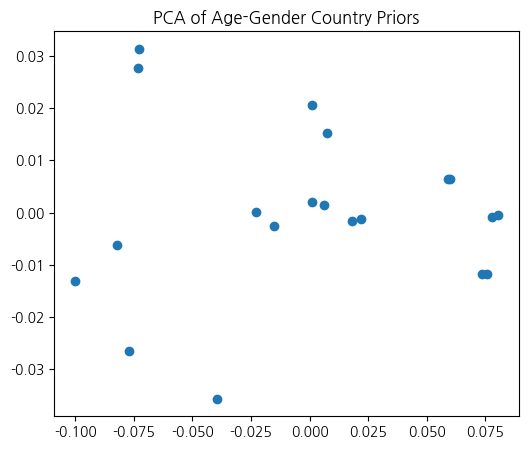

In [68]:
X = heat_df[prob_cols].values
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA of Age-Gender Country Priors")
plt.show()

- 좌우(PC1 축)로 뚜렷하게 퍼져 있음  
    - 가장 큰 분산 방향이 존재  
    - “국가 선호 축”이 하나 강하게 존재한다는 의미  
    - 앞에서 본 내용과 동일  
    US ↔ 유럽권 대립 구조  
    영어권 ↔ 유럽권 분리 구조  
<br>
- PC1 = 가장 큰 구조적 축  
"US 중심 그룹 vs 유럽 중심 그룹"을 설명  
    - 왼쪽 점들 = 유럽 성향 강한 연령대  
    - 오른쪽 점들 = US 성향 강한 연령대  
<br>
- PC2 = 세부 미세 차이  
위아래로 퍼지는 건 유럽 내부 국가 간 미묘한 차이 / 특정 연령대에서만 튀는 패턴 / NL 같은 중립 국가 영향  
<br>
- 성별 영향은 거의 없음  
성별이 국가 패턴을 크게 바꾸지 않음  
<br>
- 연령 패턴은 분명 존재  
연령이 국가 선호 구조를 이동시키는 주된 요인  

👉 국가 prior 10개는 사실상 1~2개의 축으로 설명 가능  
- 축1: 영어권 vs 유럽권  
- 축2: 유럽 내부 미세 구분  
→ 차원 축소 가능성 매우 큼  
→ 강한 다중공선성 존재  

> 모델링 관점 처리 방법 
> 1) PCA 1~2개 축만 사용  
> 2) 블록 대표 국가만 남기기  
> 3) 국가 prior 합이 1이므로, 하나 제거하고 나머지 사용  

---

### 4-3-6. 가장 중요한 국가 찾기 (분산 기준)  

어떤 국가가 연령/성별에 따라 변동이 큰지 확인  
분산 높은 국가 = 연령/성별 영향 많이 받는 국가

In [69]:
var_df = heat_df[prob_cols].var().sort_values(ascending=False)
var_df

agb_prior_us    0.002661
agb_prior_de    0.000606
agb_prior_it    0.000348
agb_prior_fr    0.000141
agb_prior_es    0.000114
agb_prior_gb    0.000022
agb_prior_au    0.000012
agb_prior_ca    0.000010
agb_prior_nl    0.000005
agb_prior_pt    0.000004
dtype: float64

- US > DE > IT 순  
<br>  
- 연령 영향의 70~80%는 US가 설명  
- 유럽권 내부에서도 차이 존재  
- 성별 영향은 거의 없음  

👉 연령 효과는 거의 US 확률 변동이 주도하며, 그 다음이 DE/IT  
👉 나머지 국가는 인구통계 영향이 매우 작음  

> 모델링 관점, 핵심 변수 후보  
> - US prior  
> - DE prior  
> - IT prior  
> 이 3개만으로도 연령 기반 구조 대부분 설명 가능  

---

## 4-4. X-train 파일 컬럼별 관계

### 4-4-1. 수치형 변수 간 관계 

- 상관계수  
    - age_missing이 가장 강함 (0.18)  
    나이가 결측인 그룹은 특정 국가 분포를 강하게 가짐  
    → age_missing은 강력한 세그먼트 변수  
    <br>  
    - agb_prior 계열이 전반적으로 상위권  
    age_gender 기반 prior는 실제 타겟과 강한 구조적 연결 존재  
    → 약한 형태의 target-aware feature  
    <br>  
    - exp_distance_km / exp_destination_km2  
    → 물리적 거리/국가 크기 등의 지리적 특성도 중요

In [70]:
from sklearn.preprocessing import LabelEncoder

num_cols = X_train.select_dtypes(include=['int64','float64']).columns

# 상관행렬
corr = X_train[num_cols].corr().abs()

le_tmp = LabelEncoder()
y_encoded = le_tmp.fit_transform(y)

corr_with_target = {}

for col in num_cols:
    corr = np.corrcoef(X_train[col], y_encoded)[0,1]
    corr_with_target[col] = corr

corr_df = pd.Series(corr_with_target).abs().sort_values(ascending=False)
corr_df.head(15)

age_missing     0.183291
agb_prior_au    0.126954
agb_prior_us    0.125020
agb_prior_ca    0.124869
agb_prior_gb    0.124391
agb_prior_pt    0.122451
agb_prior_fr    0.121597
agb_prior_es    0.121280
agb_prior_nl    0.118974
agb_prior_de    0.118378
agb_prior_it    0.116891
signup_flow     0.035252
max_secs        0.030900
total_secs      0.030271
mean_secs       0.019840
dtype: float64

- 막대 그래프  
age_missing이 확실히 튀어 있음  
그 다음은 거의 agb_prior + 거리 변수

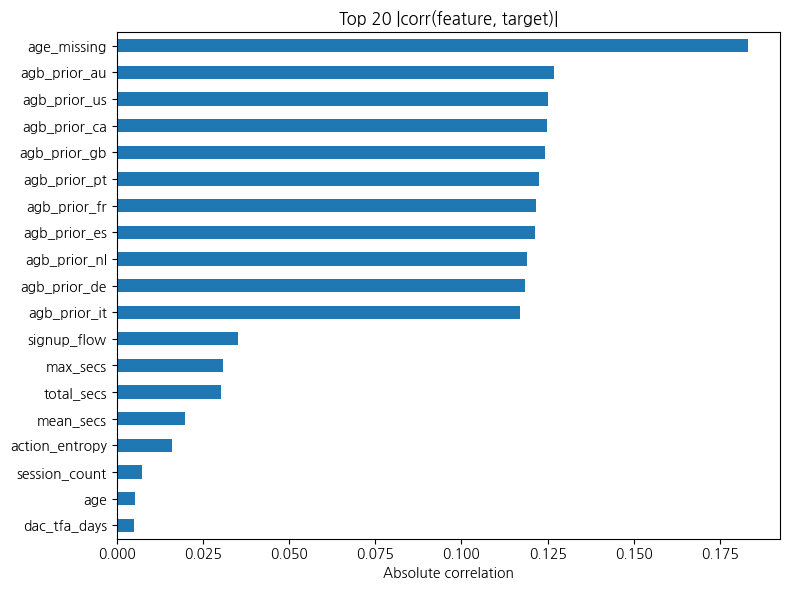

In [71]:
top_n = 20
top_corr = corr_df.head(top_n)

plt.figure(figsize=(8,6))
top_corr.sort_values().plot(kind='barh')  # 작은→큰으로 보기 편하게
plt.title(f"Top {top_n} |corr(feature, target)|")
plt.xlabel("Absolute correlation")
plt.tight_layout()
plt.show()

- 클래스별 평균 히트맵  
각 국가 클래스별로 상위 feature 평균  
<br>  
- 실제 모델은 이미 prior 기반 구조를 많이 반영하게 됨  
agb_prior_*가 다 상위  
다중공선성 매우 강함  
<br>  
- age_missing은 생각보다 강력  
<br>  
- 행동 변수보다 인구통계/지리 변수가 더 강함  
이 그래프에서는 session 행동 변수보다  
prior + 거리 변수가 더 강함  

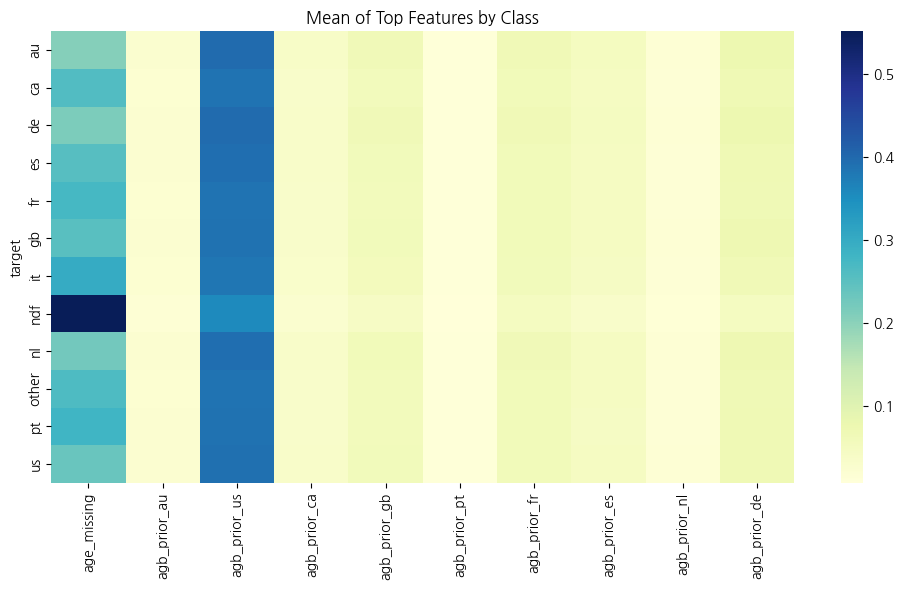

In [72]:
top_features = top_corr.index[:10]

tmp = X_train[top_features].copy()
tmp['target'] = y.values  # y가 Series면 그냥 y

mean_by_class = tmp.groupby('target')[top_features].mean()

plt.figure(figsize=(10,6))
sns.heatmap(mean_by_class, cmap='YlGnBu')
plt.title("Mean of Top Features by Class")
plt.tight_layout()
plt.show()

---

### 4-4-2. 범주형 변수 vs 타겟 관계  

- Chi-square로 관계 강도 수치화 (값 클수록 타겟과 관계 강함)  
    - id 고유값임로 제외  
    - 연령대가 국가 선택에 매우 강한 영향을 미침  
    - 성별의 영향은 연령에 비해 상대적으로 작지만,  
    다중 클래스 분포 전체 관점에서는 통계적으로 유의미한 차이가 존재함  
    - first_browser 3368  
    사용 브라우저는 국가 선택과 연결됨을 의미  
    (지역별 브라우저 점유율 차이, 언어/OS/디바이스 환경 차이 때문에 실전 모델에서 의미있는 변수일 가능성 있음)  
    - signup_app / affiliate_provider (중간 이상 강도)  
    가입 채널/앱에 따라 국가 분포 달라짐  
    마케팅 채널이 국가 선택에 영향  
    - language (생각보다 순위가 낮음)  
    이미 국가 prior에 language 영향이 반영되어, language는 직접적인 예측보단 간접적 변수로 빠짐  


👉 인구통계 + 환경 변수가 가장 강함  
👉 마케팅 경로도 의미 있음  
👉 device_type은 생각보다 약함  

In [73]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include='object').columns

chi_scores = {}

for col in cat_cols:
    X_enc = LabelEncoder().fit_transform(X_train[col].astype(str))
    chi_val, p = chi2(X_enc.reshape(-1,1), y_encoded)
    chi_scores[col] = chi_val[0]

chi_df = pd.Series(chi_scores).sort_values(ascending=False)
chi_df.head(15)

id                         518792.820484
age_bucket                  47257.502723
gender                       9074.513345
first_browser                3368.262559
signup_app                    528.279757
affiliate_provider            457.397509
language                      208.711877
signup_method                 185.027456
affiliate_channel             125.903404
first_device_type              76.829023
first_affiliate_tracked        70.939198
dtype: float64

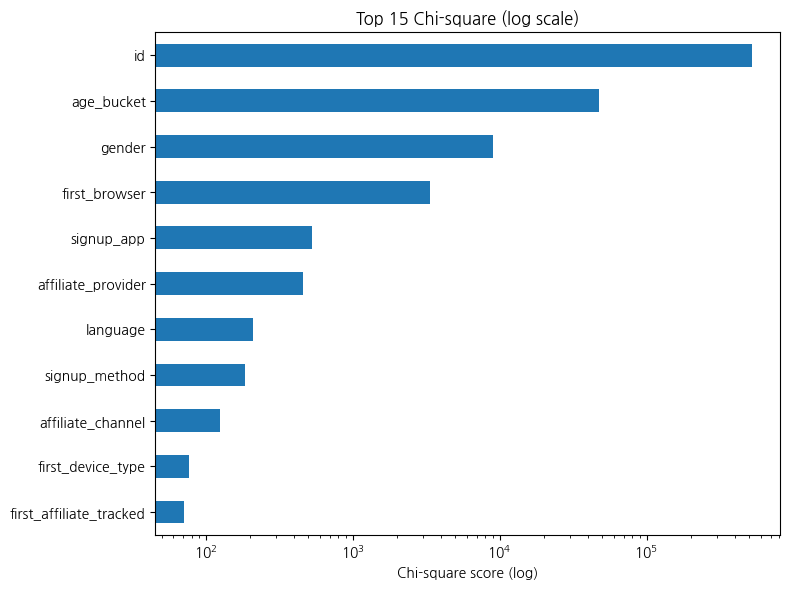

In [74]:
# 로그 스케일로 보기
top_n = 15
top_chi = chi_df.head(top_n)

plt.figure(figsize=(8,6))
top_chi.sort_values().plot(kind="barh", logx=True)
plt.title(f"Top {top_n} Chi-square (log scale)")
plt.xlabel("Chi-square score (log)")
plt.tight_layout()
plt.show()

---

### 4-4-3. Mutual Information  

- 특정 피처가 타겟에 대해 얼마나 “정보”를 주는지 측정하는 값  
값이 클수록 타겟 예측에 유용  
<br>  
    - age_missing이 여전히 1위  
    - age (연령) 자체도 매우 강함  
    - exp_destination_km2 (지리 변수)  
    - agb_prior_* 계열  
    - 행동 변수 (requested, diversity 등)  

👉 앞서 본 관계분석과 일관된 결론  
(인구통계가 가장 강함 / prior + 지리 변수도 강함 / 행동 변수는 보조적)  

👉 이 MI는 비선형 관계도 잡는데, 구조가 거의 동일하다는 것은  
모델이 복잡해지더라도 결국 핵심 축은 연령 + prior + 거리 구조 가 되어야 한다는 것  

In [75]:
from sklearn.feature_selection import mutual_info_classif

X_numeric = X_train[num_cols].fillna(0)

mi_scores = mutual_info_classif(X_numeric, y_encoded)

mi_df = pd.Series(mi_scores, index=num_cols).sort_values(ascending=False)
mi_df.head(15)

age_missing       0.062113
age               0.049857
agb_prior_us      0.028654
agb_prior_pt      0.028306
agb_prior_ca      0.027503
agb_prior_gb      0.027349
agb_prior_fr      0.026706
agb_prior_de      0.026409
agb_prior_it      0.026107
agb_prior_nl      0.026082
agb_prior_au      0.025694
agb_prior_es      0.025330
action_entropy    0.016895
signup_flow       0.010719
mean_secs         0.008738
dtype: float64

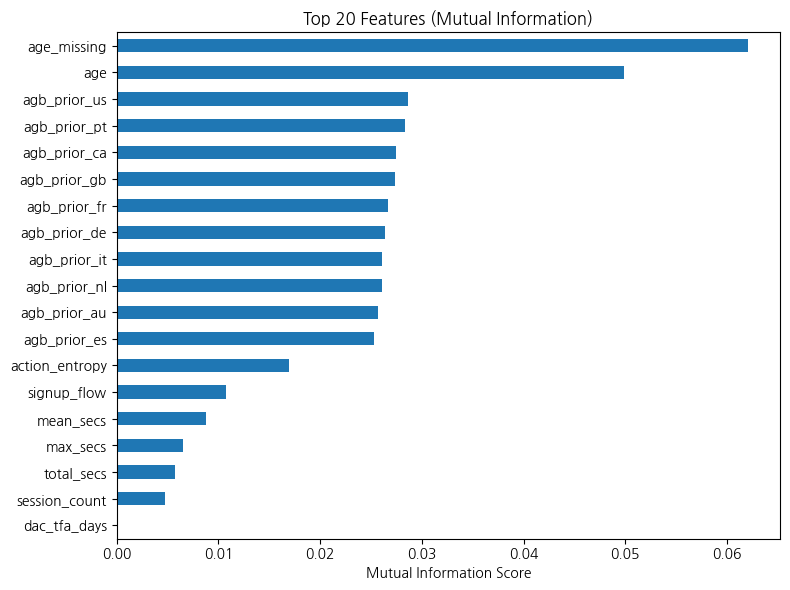

In [76]:
top_n = 20
top_mi = mi_df.head(top_n)

plt.figure(figsize=(8,6))
top_mi.sort_values().plot(kind='barh')
plt.title(f"Top {top_n} Features (Mutual Information)")
plt.xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

---

### 4-4-4. Train vs Test 분포 차이 수치화 (KS statistic)  

- 값 범위 : 0 ~ 1  
- 두 분포의 누적분포(CDF) 차이의 최대값  
(0에 가까울수록 train/test 분포가 거의 동일)  

In [77]:
from scipy.stats import ks_2samp

shift_scores = {}

for col in num_cols:
    stat, p = ks_2samp(X_train[col].dropna(), X_test[col].dropna())
    shift_scores[col] = stat

shift_df = pd.Series(shift_scores).sort_values(ascending=False)
shift_df.head(10)

session_count     0.654239
action_entropy    0.654154
total_secs        0.652440
max_secs          0.651512
mean_secs         0.651404
signup_flow       0.199685
agb_prior_pt      0.090697
agb_prior_de      0.090697
agb_prior_es      0.090697
agb_prior_it      0.090697
dtype: float64

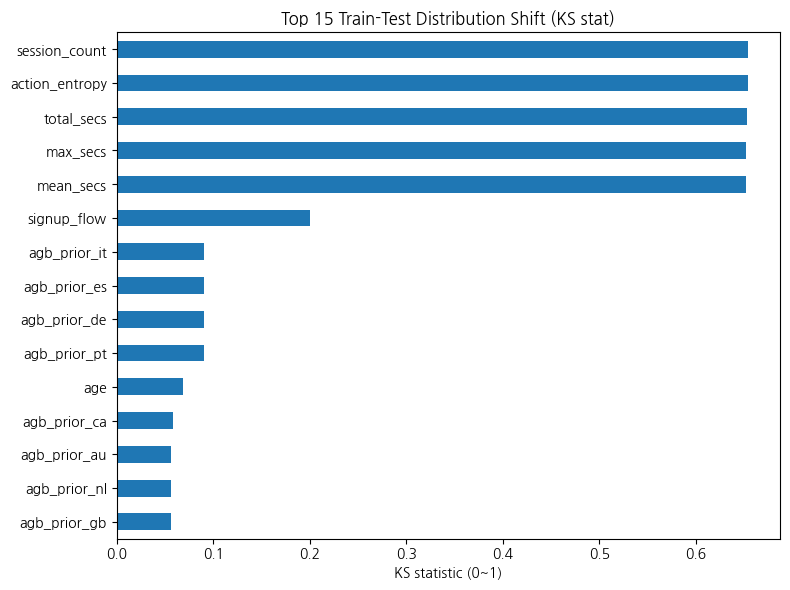

In [78]:
top_n = 15
top_shift = shift_df.head(top_n)

plt.figure(figsize=(8,6))
top_shift.sort_values().plot(kind="barh")
plt.title(f"Top {top_n} Train-Test Distribution Shift (KS stat)")
plt.xlabel("KS statistic (0~1)")
plt.tight_layout()
plt.show()

- 현재 KS 수치가 매우 높은 상태로 거의 다른 데이터셋으로 나옴  
→ 이는 Train/Test 파일이 시간 기준으로 분리되었기 때문임 (설계 전략 문제)  
    - train : 2010-01-01 ~ 2014-06-30   
    - test : 2014-07-01 ~ 2014-09-30  

> - 처리 방법  
    - 시간 인지(Time-aware) 학습 +  
    - 행동 변수는 안정화(로그/구간화) +  
    - 최근 데이터에 가중치 부여  

---

## 4-5. EDA 정리

**🎯 프로젝트 목적**  
- 어떤 환경(기기)에서 어떤 경로로 들어온, 몇 살의 유저가 어디를 갈까?  
→ 사용자 특성 + 가입 시점 + 유입 경로 + 기기 환경을 기반으로  
→ 최종 여행 국가(country_destination)를 예측하는 것이 목적  

<br>

**📌 행동 기반 세션 정보가 가장 강력한 예측 신호이며, 가입 경로 및 기기 환경이 이를 보조하는 구조**  
- 영향도 높은 순  
    - Sessions 행동 변수
    - 가입 채널/방법
    - 기기 환경
    - 연령
    - Countries prior



---

# 5️⃣ 모델링


> - 로지스틱 회귀 (베이스라인)  
> - LightGBM    
> - CatBoost  

In [79]:
# 준비: y 인코딩 + X 정렬

from sklearn.preprocessing import LabelEncoder

# 1) 제출용 id 보관
test_ids = X_test['id'].astype(str).values

# 2) 모델 입력에서는 id 제거
X_train_m = X_train.drop(columns=['id']).copy()
X_test_m  = X_test.drop(columns=['id']).copy()

# 3) train/test 컬럼 정렬 맞추기 (train 기준)
X_test_m = X_test_m.reindex(columns=X_train_m.columns, fill_value=0)

# 4) 타겟 인코딩
y = y.astype(str).str.strip().str.lower()
le = LabelEncoder()
y_enc = le.fit_transform(y)
classes = list(le.classes_)
print("num classes:", len(classes), classes)

num classes: 12 ['au', 'ca', 'de', 'es', 'fr', 'gb', 'it', 'ndf', 'nl', 'other', 'pt', 'us']


In [80]:
# 범주형 컬럼 지정

cat_candidates = [
    'gender','signup_method','language',
    'affiliate_channel','affiliate_provider',
    'first_affiliate_tracked','signup_app',
    'first_device_type','first_browser',
    'signup_flow','age_bucket'
]
cat_cols = [c for c in cat_candidates if c in X_train_m.columns]
print("categorical cols:", cat_cols)

categorical cols: ['gender', 'signup_method', 'language', 'affiliate_channel', 'affiliate_provider', 'first_affiliate_tracked', 'signup_app', 'first_device_type', 'first_browser', 'signup_flow', 'age_bucket']


In [81]:
# 공통: Train/Valid Split + 평가 함수

from sklearn.model_selection import train_test_split

# NDCG@5 : 정답이 Top5 안에 들어왔는지 + 몇 번째에 있는지를 평가하는 함수
def ndcg_at_k(y_true_str, y_prob, classes, k=5):
    topk_idx = np.argsort(y_prob, axis=1)[:, -k:][:, ::-1]
    topk_labels = np.array(classes)[topk_idx]

    gains = np.zeros(len(y_true_str), dtype=float)
    for i in range(len(y_true_str)):
        match = np.where(topk_labels[i] == y_true_str[i])[0]
        if len(match) > 0:
            rank = match[0] + 1
            gains[i] = 1.0 / np.log2(rank + 1)
    return gains.mean()

# Top-1 Accuracy
def top1_accuracy(y_true_enc, y_prob):
    pred = np.argmax(y_prob, axis=1)
    return (pred == y_true_enc).mean()

# Split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_m, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

y_val_str = le.inverse_transform(y_val)

print("Train:", X_tr.shape)
print("Valid:", X_val.shape)

Train: (170760, 32)
Valid: (42691, 32)


## 5-1. 로지스틱 회귀 (베이스라인)

In [82]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 'dac_ym' Period → datetime으로 바꾸기
period_cols = [c for c in X_tr.columns 
               if isinstance(X_tr[c].dtype, pd.PeriodDtype)]

for c in period_cols:
    # Period -> Timestamp
    if isinstance(X_tr[c].dtype, pd.PeriodDtype):
        X_tr[c] = X_tr[c].dt.to_timestamp()
        X_val[c] = X_val[c].dt.to_timestamp()
    else:
        # 혹시 문자열/오브젝트면 datetime으로 파싱
        X_tr[c] = pd.to_datetime(X_tr[c], errors="coerce")
        X_val[c] = pd.to_datetime(X_val[c], errors="coerce")

    # datetime -> int64 (모델용 숫자)
    X_tr[c] = X_tr[c].view("int64")
    X_val[c] = X_val[c].view("int64")

# 범주형/수치형 분리
cat_cols_lr = [c for c in cat_cols if c in X_train_m.columns]
num_cols_lr = [c for c in X_train_m.columns if c not in cat_cols_lr]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_lr),
        ("num", StandardScaler(with_mean=False), num_cols_lr),
    ]
)

lr = LogisticRegression(
    multi_class="multinomial",
    solver="saga",
    max_iter=2000,
    C=1.0,
    n_jobs=-1
)

lr_model = Pipeline([("prep", preprocess), ("lr", lr)])
lr_model.fit(X_tr, y_tr)

lr_val_prob = lr_model.predict_proba(X_val)

score_lr_ndcg = ndcg_at_k(y_val_str, lr_val_prob, classes)
score_lr_acc = top1_accuracy(y_val, lr_val_prob)

print("LogisticRegression")
print("NDCG@5:", score_lr_ndcg)
print("Accuracy:", score_lr_acc)

LogisticRegression
NDCG@5: 0.8244142033390633
Accuracy: 0.6315851116160315


## 5-2. LightGBM

In [83]:
# LightGBM 학습/예측

!pip install lightgbm
import lightgbm as lgb

# LightGBM은 category dtype 권장
X_tr_lgb = X_tr.copy()
X_val_lgb = X_val.copy()

for c in cat_cols:
    if c in X_tr_lgb.columns:
        X_tr_lgb[c] = X_tr_lgb[c].astype("category")
        X_val_lgb[c] = X_val_lgb[c].astype("category")

lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(classes),
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

lgb_model.fit(
    X_tr_lgb, y_tr,
    categorical_feature=[c for c in cat_cols if c in X_tr_lgb.columns]
)

lgb_val_prob = lgb_model.predict_proba(X_val_lgb)

score_lgb_ndcg = ndcg_at_k(y_val_str, lgb_val_prob, classes)
score_lgb_acc = top1_accuracy(y_val, lgb_val_prob)

print("\nLightGBM")
print("NDCG@5:", score_lgb_ndcg)
print("Accuracy:", score_lgb_acc)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1816
[LightGBM] [Info] Number of data points in the train set: 170760, number of used features: 32
[LightGBM] [Info] Start training from score -5.981906
[LightGBM] [Info] Start training from score -5.007478
[LightGBM] [Info] Start training from score -5.303955
[LightGBM] [Info] Start training from score -4.553028
[LightGBM] [Info] Start training from score -3.749475
[LightGBM] [Info] Start training from score -4.520220
[LightGBM] [Info] Start training from score -4.321361
[LightGBM] [Info] Start training from score -0.538756
[LightGBM] [Info] Start training from score -5.634555
[LightGBM] [Info] Start training from score -3.051486
[LightGBM] [Info] Start training from score -6.888959
[LightGBM] [Info] Start training from score -1.23021

## 5-3. CatBoost

In [84]:
!pip install catboost
from catboost import CatBoostClassifier

# CatBoost는 cat_features를 인덱스로 받는 게 편함
cat_idx = [X_tr.columns.get_loc(c) for c in cat_cols if c in X_tr.columns]

cb_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.08,       # 0.1보다 안정적인 편
    depth=6,
    l2_leaf_reg=3,                    # 과적합 줄이기 / 3~10 범위 탐색
    random_strength=1.0,              # 과적합 줄이기 / 0.5~2 정도
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_seed=42,
    verbose=200,

    # 속도 옵션
    thread_count=-1,
    border_count=128,             # (기본 254) 줄이면 조금 빨라짐
    one_hot_max_size=10,          # 카테고리 처리 속도/안정
)

# y를 Series로 맞추기(인덱스 정렬 목적)
y_tr_s  = pd.Series(y_tr, index=X_tr.index)
y_val_s = pd.Series(y_val, index=X_val.index)

cb_model.fit(
    X_tr, y_tr_s,
    cat_features=cat_idx,
    eval_set=(X_val, y_val_s),
    use_best_model=True,
    early_stopping_rounds=50
)

cb_val_prob = cb_model.predict_proba(X_val)

score_cb_ndcg = ndcg_at_k(y_val_str, cb_val_prob, classes)
score_cb_acc  = top1_accuracy(y_val, cb_val_prob)

print("\nCatBoost(full train)")
print("NDCG@5:", score_cb_ndcg)
print("Accuracy:", score_cb_acc)

0:	learn: 2.1173841	test: 2.1170190	best: 2.1170190 (0)	total: 1.72s	remaining: 57m 23s
200:	learn: 1.0327255	test: 1.0463219	best: 1.0463219 (200)	total: 5m 52s	remaining: 52m 35s
400:	learn: 1.0153888	test: 1.0435573	best: 1.0435573 (400)	total: 12m	remaining: 47m 53s
600:	learn: 1.0028801	test: 1.0429746	best: 1.0429507 (595)	total: 17m 47s	remaining: 41m 24s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1.042950711
bestIteration = 595

Shrink model to first 596 iterations.

CatBoost(full train)
NDCG@5: 0.8279058858854811
Accuracy: 0.6425710337073388


## 5-4. 모델 결과 비교

In [85]:
results = pd.DataFrame({
    "Model": ["LogisticRegression", "LightGBM", "CatBoost"],
    "NDCG@5": [score_lr_ndcg, score_lgb_ndcg, score_cb_ndcg],
    "Accuracy": [score_lr_acc, score_lgb_acc, score_cb_acc]
})

results = results.sort_values("NDCG@5", ascending=False)
results

,Model,NDCG@5,Accuracy
2,CatBoost,0.827906,0.642571
0,LogisticRegression,0.824414,0.631585
1,LightGBM,0.824249,0.635286


---

# 6️⃣ 추가 작업

## 6-1. countries 파일

### 6-1-1. 확률 후처리용 가중치(adj) 만들기

- 본 파일은 국가별 통계(거리, 언어 거리, 인구 등) 정보  
- `country_destination`, 타겟 변수 있음  
- 모델 피처로 직접 merge 할 수 없으니, 예측 결과(확률)를 '사후적으로' 살짝 보정하는 후처리  
- 예측 확률을 '국가 특성으로 재가중'하기  

In [86]:
bnb_country_df

,country_destination,lat_destination,lng_destination,distance_km,destination_km2,destination_language,language_levenshtein_distance
0,au,-26.853388,133.275160,15297.7440,7741220.0,eng,0.00
1,ca,62.393303,-96.818146,2828.1333,9984670.0,eng,0.00
2,de,51.165707,10.452764,7879.5680,357022.0,deu,72.61
3,es,39.896027,-2.487694,7730.7240,505370.0,spa,92.25
4,fr,46.232193,2.209667,7682.9450,643801.0,fra,92.06
5,gb,54.633220,-3.432277,6883.6590,243610.0,eng,0.00
6,it,41.873990,12.564167,8636.6310,301340.0,ita,89.40
7,nl,52.133057,5.295250,7524.3203,41543.0,nld,63.22
8,pt,39.553444,-7.839319,7355.2534,92090.0,por,95.45
9,us,36.966427,-95.844030,0.0000,9826675.0,eng,0.00


- countries 스코어 만들기  
국가별 숫자 통계들을 이용해 “국가 선호도 스코어(가중치)”를 만들고,  
모델의 P(country | user)에 그 가중치를 곱한 뒤 다시 정규화해서 P’ 만들기  

$$
P'(c|x) = \frac{P(c|x)⋅w_c}{\sum_kP(k|x)⋅w_k}
$$
- 여기서 `w_c`가 `build_country_adjustment()`에서 만든 조정값(adj)

In [87]:
def build_country_adjustment(countries_df, all_countries):
    c = countries_df.copy()
    c = normalize_object_cols(c)

    # country_destination이 키
    if 'country_destination' not in c.columns:
        raise ValueError("countries.csv에 country_destination 컬럼이 없습니다.")

    c = c.set_index('country_destination')

    # 사용할만한 수치 컬럼 후보 (있는 것만 사용)
    numeric_cols = [col for col in c.columns if pd.api.types.is_numeric_dtype(c[col])]
    if len(numeric_cols) == 0:
        # 수치가 없으면 조정 못 함
        adj = pd.Series(1.0, index=all_countries)
        return adj

    # 간단한 방식: 모든 수치컬럼 z-score 합으로 “선호 스코어”를 만들고 sigmoid로 변환
    X = c[numeric_cols].copy()

    # 결측 처리
    X = X.fillna(X.median(numeric_only=True))

    # z-score 
    # 각 국가의 수치 컬럼들은 스케일이 달라 (인구, 거리, 면적 등)
    # 그래서 표준화해서 “서로 비교 가능”하게 만들려고 z-score를 씀
    Xz = (X - X.mean()) / (X.std().replace(0, 1))

    # 스코어(원하는 방향이 명확치 않으니, 절댓값이 큰 것은 불리하다고 가정하는 보수적 방식)
    # abs(z)가 크면 패널티를 주는 방식 (극단값 국가를 살짝 깎는 방향)
    score = (-Xz.abs()).sum(axis=1)

    # 0~1 스케일 변환
    adj = 1 / (1 + np.exp(-score))

    # 필요한 나라만
    adj = adj.reindex(all_countries).fillna(1.0)

    # NDF는 국가가 아니므로 1.0 유지
    # NDF는 실제 국가가 아니라 “예약 없음”이라 countries.csv에 국가 통계가 없고,
    # 후처리로 건드리면 이상해질 수 있어서 그대로 둠
    if 'ndf' in adj.index:
        adj.loc['ndf'] = 1.0

    return adj

- 확률에 조정 적용 (optional)

In [88]:
def adjust_probs_with_country_alpha(pr, all_countries, adj_series, alpha=0.3):
    w = np.array([adj_series.get(c.lower(), 1.0) for c in all_countries], dtype=float)
    w = np.power(w, alpha)  # 강도 조절
    pr2 = pr * w
    pr2 = pr2 / pr2.sum(axis=1, keepdims=True)
    return pr2

classes: ['au', 'ca', 'de', 'es', 'fr', 'gb', 'it', 'ndf', 'nl', 'other', 'pt', 'us']
Top weights:
country_destination
ndf      1.000000
other    1.000000
es       0.157297
nl       0.154686
pt       0.143707
fr       0.123469
de       0.122576
it       0.099059
gb       0.079246
us       0.002258
dtype: float64

Bottom weights:
country_destination
es    0.157297
nl    0.154686
pt    0.143707
fr    0.123469
de    0.122576
it    0.099059
gb    0.079246
us    0.002258
ca    0.001977
au    0.000106
dtype: float64


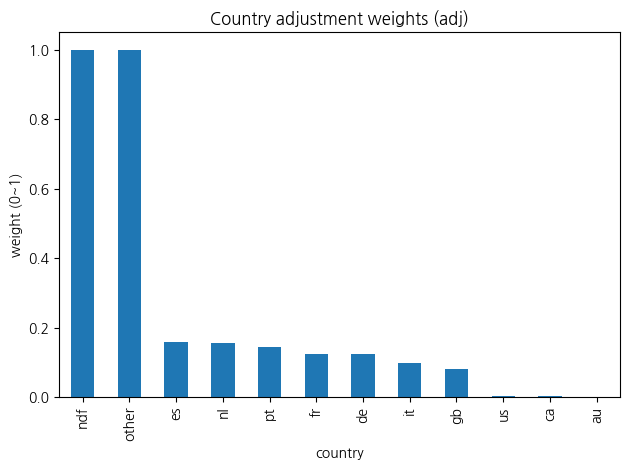

In [89]:
from sklearn.preprocessing import LabelEncoder

def normalize_object_cols(df, exclude_cols=()):
    df = df.copy()
    obj_cols = df.select_dtypes(include="object").columns
    for c in obj_cols:
        if c in exclude_cols:
            continue
        df[c] = (
            df[c]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace({"nan": np.nan})
        )
    return df

le = LabelEncoder()
le.fit(y)

classes = list(le.classes_)
print("classes:", classes)

adj = build_country_adjustment(bnb_country_df, classes)

# 1) 가중치 확인(큰/작은 나라)
adj_sorted = adj.sort_values(ascending=False)
print("Top weights:")
print(adj_sorted.head(10))
print("\nBottom weights:")
print(adj_sorted.tail(10))

# 2) 분포 확인
import matplotlib.pyplot as plt
plt.figure()
adj_sorted.plot(kind='bar')
plt.title("Country adjustment weights (adj)")
plt.xlabel("country")
plt.ylabel("weight (0~1)")
plt.tight_layout()
plt.show()

- `ndf=1.0`, `other=1.0`  
- `us≈0.002`, `ca≈0.002`, `au≈0.0001` …  


- 국가별 가중치가 너무 극단적으로 작아져서 `pr * adj` 하면  
US/CA/AU 같은 확률이 거의 0으로 눌릴 가능성이 크므로,  
alpha로 조정 강도 튜닝하여 `adj ** alpha`로 완화하기

### 6-1-2. Prior Feature

In [90]:
# countries 정리
c = bnb_country_df.copy()
c = c.set_index('country_destination')

# countries 수치 컬럼 정리
cand_stats = ['distance_km', 'destination_km2', 'language_levenshtein_distance', 'population_in_thousands']
use_stats = [s for s in cand_stats if s in c.columns]
print("use_stats:", use_stats)

# classes normalize
classes = [str(x).strip().lower() for x in list(le.classes_)]

# 기대값 prior feature 생성 함수
def add_country_prior_expected_features(X, classes, countries_df, prior_prefix='agb_prior_'):
    X = X.copy()
    for stat in use_stats:
        stat_map = countries_df[stat].to_dict()
        terms = []
        for cc in classes:
            pcol = f"{prior_prefix}{cc}"
            if pcol in X.columns:
                terms.append(X[pcol].astype(float) * float(stat_map.get(cc, 0.0)))
        X[f"exp_{stat}"] = np.sum(terms, axis=0) if len(terms) else 0.0
    return X

X_train = add_country_prior_expected_features(X_train, classes, c)
X_test  = add_country_prior_expected_features(X_test, classes, c)

print([col for col in X_train.columns if col.startswith("exp_")])
display(X_train[[col for col in X_train.columns if col.startswith("exp_")]].head())

use_stats: ['distance_km', 'destination_km2', 'language_levenshtein_distance']
['exp_distance_km', 'exp_destination_km2', 'exp_language_levenshtein_distance']


,exp_distance_km,exp_destination_km2,exp_language_levenshtein_distance
0,582.963797,2.987105e+06,5.009403
1,4324.437577,5.306665e+06,32.644530
2,4324.827238,5.234588e+06,33.265663
3,4551.254430,4.986763e+06,35.207638
4,582.963797,2.987105e+06,5.009403


---

# 7️⃣ 모델링 성능 개선 

## 7-1. 앙상블(Ensemble)

여러 모델을 함께 사용해서 하나의 더 강한 모델을 만드는 방법  

In [91]:
# 공통: 확률 앙상블 함수
def blend_probs(p1, p2, w1):
    """w1*p1 + (1-w1)*p2 후 row-wise 정규화"""
    p = w1 * p1 + (1.0 - w1) * p2
    p = p / p.sum(axis=1, keepdims=True)
    return p

def blend_probs3(p1, p2, p3, w1, w2):
    """w1*p1 + w2*p2 + (1-w1-w2)*p3 후 row-wise 정규화"""
    w3 = 1.0 - w1 - w2
    p = w1 * p1 + w2 * p2 + w3 * p3
    p = p / p.sum(axis=1, keepdims=True)
    return p

# 2개 앙상블: best weight 찾기
def search_best_w_2(pA, pB, nameA="A", nameB="B", step=0.01):
    grid = np.arange(0, 1 + 1e-9, step)
    best_score = -1
    best_w = None

    for w in grid:
        ens = blend_probs(pA, pB, w)
        score = ndcg_at_k(y_val_str, ens, classes, k=5)
        if score > best_score:
            best_score = score
            best_w = w

    # best 가중치에서 acc도 같이 출력
    best_ens = blend_probs(pA, pB, best_w)
    best_acc = top1_accuracy(y_val, best_ens)

    print(f"[{nameA}+{nameB}] BEST NDCG@5={best_score:.6f}  w({nameA})={best_w:.3f}  w({nameB})={1-best_w:.3f}  Acc={best_acc:.6f}")
    return best_score, best_w, best_ens

# 3개 앙상블: best weights 찾기
def search_best_w_3(pLR, pLGB, pCB, step=0.05):
    grid = np.arange(0, 1 + 1e-9, step)
    best_score = -1
    best = None

    for w_lr in grid:
        for w_lgb in grid:
            w_cb = 1.0 - w_lr - w_lgb
            if w_cb < 0:
                continue
            ens = blend_probs3(pLR, pLGB, pCB, w_lr, w_lgb)
            score = ndcg_at_k(y_val_str, ens, classes, k=5)
            if score > best_score:
                best_score = score
                best = (w_lr, w_lgb, w_cb)

    w_lr, w_lgb, w_cb = best
    best_ens = blend_probs3(pLR, pLGB, pCB, w_lr, w_lgb)
    best_acc = top1_accuracy(y_val, best_ens)

    print(f"[LR+LGB+CB] BEST NDCG@5={best_score:.6f}  w_lr={w_lr:.3f} w_lgb={w_lgb:.3f} w_cb={w_cb:.3f}  Acc={best_acc:.6f}")
    return best_score, best, best_ens


# 실행: 2개 조합 3개 + (원하면) 3개 조합

# 1) LR + LGB
score_lr_lgb, w_lr_in_lr_lgb, ens_lr_lgb = search_best_w_2(
    lr_val_prob, lgb_val_prob, nameA="LR", nameB="LGB", step=0.01
)

# 2) LR + CB
score_lr_cb, w_lr_in_lr_cb, ens_lr_cb = search_best_w_2(
    lr_val_prob, cb_val_prob, nameA="LR", nameB="CB", step=0.01
)

# 3) LGB + CB
score_lgb_cb, w_lgb_in_lgb_cb, ens_lgb_cb = search_best_w_2(
    lgb_val_prob, cb_val_prob, nameA="LGB", nameB="CB", step=0.01
)

# (선택) 4) LR + LGB + CB
# step=0.05면 빠름, step=0.02면 좀 더 촘촘하지만 느려짐
score_3, best_w3, ens_3 = search_best_w_3(
    lr_val_prob, lgb_val_prob, cb_val_prob, step=0.05
)

# 결과 요약 표
import pandas as pd
res = pd.DataFrame([
    {"Ensemble": "LR+LGB", "NDCG@5": score_lr_lgb, "w1": w_lr_in_lr_lgb, "w2": 1-w_lr_in_lr_lgb},
    {"Ensemble": "LR+CB",  "NDCG@5": score_lr_cb,  "w1": w_lr_in_lr_cb,  "w2": 1-w_lr_in_lr_cb},
    {"Ensemble": "LGB+CB", "NDCG@5": score_lgb_cb, "w1": w_lgb_in_lgb_cb, "w2": 1-w_lgb_in_lgb_cb},
    {"Ensemble": "LR+LGB+CB", "NDCG@5": score_3, "w1": best_w3[0], "w2": best_w3[1], "w3": best_w3[2]},
]).sort_values("NDCG@5", ascending=False)

res

[LR+LGB] BEST NDCG@5=0.826586  w(LR)=0.430  w(LGB)=0.570  Acc=0.638612
[LR+CB] BEST NDCG@5=0.827906  w(LR)=0.000  w(CB)=1.000  Acc=0.642571
[LGB+CB] BEST NDCG@5=0.828216  w(LGB)=0.170  w(CB)=0.830  Acc=0.642758
[LR+LGB+CB] BEST NDCG@5=0.828287  w_lr=0.050 w_lgb=0.150 w_cb=0.800  Acc=0.642969


,Ensemble,NDCG@5,w1,w2,w3
3,LR+LGB+CB,0.828287,0.05,0.15,0.8
2,LGB+CB,0.828216,0.17,0.83,NaN
1,LR+CB,0.827906,0.00,1.00,NaN
0,LR+LGB,0.826586,0.43,0.57,NaN


- CatBoost 가 가장 강한 모델  
로지스틱 회귀와 LightGBM은 보조 모델 역할  

- 모델 3개 앙상블이 가장 성능이 좋다고 나오지만,  
LGB+CB랑 차이 거의 없음 (0.00006 수준)  
LGB+CB만 써도 충분히 안정적임을 확인  

In [92]:
# test 파일 컬럼/형태 준비

# LightGBM용
X_test_lgb = X_test_m.copy()
for c in cat_cols:
    if c in X_test_lgb.columns:
        X_test_lgb[c] = X_test_lgb[c].astype("category")

lgb_test_prob = lgb_model.predict_proba(X_test_lgb)

# LightGBM용
cb_test_prob = cb_model.predict_proba(X_test_m)

In [93]:
# 앙상블 확률 만들기

# LGB+CB 베스트 가중치
w_lgb = 0.17
w_cb = 1.0 - w_lgb  # 0.83

# val/test 앙상블 확률 만들기
base_val  = blend_probs(lgb_val_prob, cb_val_prob, w_lgb)
base_test = blend_probs(lgb_test_prob, cb_test_prob, w_lgb)

print("base_val shape:", base_val.shape)
print("base_test shape:", base_test.shape)

base_val shape: (42691, 12)
base_test shape: (62096, 12)


---

## 7-2. countries 파일 활용 모델 튜닝
7-1에서 뽑은 앙상블 확률과  
6에서 countries 파일의 후처리용 가중치 및 Prior Feature 사용하여  
2차 튜닝 진행

In [94]:
# 공통 유틸 (정규화 + metric)
def row_normalize(p, eps=1e-12):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, None)
    return p / p.sum(axis=1, keepdims=True)

def ndcg_at_k(y_true_str, y_prob, classes, k=5):
    topk_idx = np.argsort(y_prob, axis=1)[:, -k:][:, ::-1]
    topk_labels = np.array(classes)[topk_idx]
    gains = np.zeros(len(y_true_str), dtype=float)

    for i in range(len(y_true_str)):
        match = np.where(topk_labels[i] == y_true_str[i])[0]
        if len(match) > 0:
            rank = match[0] + 1
            gains[i] = 1.0 / np.log2(rank + 1)
    return gains.mean()

In [95]:
# prior 행렬 만들기 (val/test 둘 다)
def get_prior_matrix_safe(X_df, classes, prior_prefix="agb_prior_"):
    # classes 순서대로 prior 컬럼 만들되, 없는 건 0으로 채움
    cols = [f"{prior_prefix}{c}" for c in classes]
    prior_df = pd.DataFrame(index=X_df.index)

    for col in cols:
        if col in X_df.columns:
            prior_df[col] = X_df[col].astype(float)
        else:
            prior_df[col] = 0.0

    prior = prior_df.values
    row_sum = prior.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0  # 전부 0이면 그대로 0 유지(나눗셈 방지)
    prior = prior / row_sum
    return prior

prior_val  = get_prior_matrix_safe(X_val,  classes, "agb_prior_")
prior_test = get_prior_matrix_safe(X_test, classes, "agb_prior_")

def blend_with_prior(p, prior, beta):
    return row_normalize((1 - beta) * p + beta * prior)

alphas = [0.0, 0.03, 0.05, 0.1, 0.2, 0.4]
betas  = [0.0, 0.03, 0.05, 0.1, 0.15, 0.2]

best = (-1, None)
best_p = None

for a in alphas:
    p_a = adjust_probs_with_country_alpha(base_val, classes, adj, alpha=a)
    for b in betas:
        p_ab = blend_with_prior(p_a, prior_val, beta=b)
        s = ndcg_at_k(y_val_str, p_ab, classes, k=5)
        if s > best[0]:
            best = (s, a, b)
            best_p = p_ab

print("BEST:", best)  # (best_ndcg, best_alpha, best_beta)
print("BEST ACC:", top1_accuracy(y_val, best_p))

BEST: (np.float64(0.8282393797097036), 0.0, 0.03)
BEST ACC: 0.6428052751165351


- `alpha=0`이므로, countries 후처리 영향이 없음을 확인 (안 한 것과 동일)  
- `beta=0.03` : prior는 아주 약하게(3%) 섞는게 좋음  
<br>
- 결과 확인 :  
(앙상블 NDCG@5) 0.828216  
(countries파일 prior 적용 NDCG@5) 0.828239  
→ +0.000023  


In [96]:
# test 적용 코드

# 베스트 파라미터
best_alpha = 0.0
best_beta  = 0.03

# countries 영향 없음
p_test_a = base_test  # alpha=0 이므로 그대로

# prior만 살짝 섞기
p_test_final = blend_with_prior(p_test_a, prior_test, beta=best_beta)

---

## 7-3. test 확률 예측

- train 기준 컬럼 정렬 + LightGBM용 category 캐스팅

In [97]:
# test_ids
test_ids = X_test["id"].astype(str).values

# 모델 입력용(id 제거)
X_test_m = X_test.drop(columns=["id"]).copy()

# (중요) train 기준 컬럼 정렬/누락 컬럼 채우기
X_test_m = X_test_m.reindex(columns=X_train_m.columns, fill_value=0)

# LightGBM용 category 캐스팅 데이터프레임 만들기
X_test_lgb = X_test_m.copy()
for c in cat_cols:
    if c in X_test_lgb.columns:
        X_test_lgb[c] = X_test_lgb[c].astype("category")

- train 기준 컬럼 정렬 + LightGBM용 category 캐스팅

In [98]:
# LR
lr_test_prob = lr_model.predict_proba(X_test_m)

# LGB
lgb_test_prob = lgb_model.predict_proba(X_test_lgb)

# CB (CatBoost는 cat_features index 필요)
cb_test_prob = cb_model.predict_proba(X_test_m)

- sanity check (shape / row-sum / nan)

In [99]:
def sanity(p, name):
    import numpy as np
    print(f"[{name}] shape:", p.shape)
    print(f"[{name}] row_sum mean:", np.mean(p.sum(axis=1)))
    print(f"[{name}] nan:", np.isnan(p).any(), "inf:", np.isinf(p).any())

sanity(lr_test_prob,  "LR")
sanity(lgb_test_prob, "LGB")
sanity(cb_test_prob,  "CB")
print("n_classes:", len(classes))

[LR] shape: (62096, 12)
[LR] row_sum mean: 1.0
[LR] nan: False inf: False
[LGB] shape: (62096, 12)
[LGB] row_sum mean: 1.0
[LGB] nan: False inf: False
[CB] shape: (62096, 12)
[CB] row_sum mean: 1.0
[CB] nan: False inf: False
n_classes: 12


- 베스트 앙상블(LGB+CB) 적용

In [100]:
def row_normalize(p, eps=1e-12):
    import numpy as np
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, None)
    return p / p.sum(axis=1, keepdims=True)

def blend_probs(p1, p2, w1):
    return row_normalize(w1 * p1 + (1.0 - w1) * p2)

w_lgb = 0.17
base_test = blend_probs(lgb_test_prob, cb_test_prob, w_lgb)
print("base_test shape:", base_test.shape)

base_test shape: (62096, 12)


- prior 후처리 beta=0.03 적용

In [101]:
def get_prior_matrix_safe(X_df, classes, prior_prefix="agb_prior_"):
    import numpy as np
    import pandas as pd

    cols = [f"{prior_prefix}{c}" for c in classes]
    prior_df = pd.DataFrame(index=X_df.index)

    for col in cols:
        prior_df[col] = X_df[col].astype(float) if col in X_df.columns else 0.0

    prior = prior_df.values
    row_sum = prior.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0
    return prior / row_sum

prior_test = get_prior_matrix_safe(X_test_m, classes, "agb_prior_")

def blend_with_prior(p, prior, beta):
    return row_normalize((1 - beta) * p + beta * prior)

beta = 0.03
final_test = blend_with_prior(base_test, prior_test, beta=beta)
print("final_test shape:", final_test.shape)

final_test shape: (62096, 12)


---

## 7-4. 제출용 top5 생성

In [102]:
import numpy as np
import pandas as pd

top5_idx = np.argsort(final_test, axis=1)[:, -5:][:, ::-1]
top5_labels = np.array(classes)[top5_idx]

sub = pd.DataFrame({
    "id": np.repeat(test_ids, 5),
    "country": top5_labels.reshape(-1)
})

sub.to_csv("submission.csv", index=False)
sub.head(10)

,id,country
0,5uwns89zht,ndf
1,5uwns89zht,us
2,5uwns89zht,fr
3,5uwns89zht,es
4,5uwns89zht,other
5,jtl0dijy2j,ndf
6,jtl0dijy2j,us
7,jtl0dijy2j,fr
8,jtl0dijy2j,es
9,jtl0dijy2j,gb


---

# 8️⃣ 모델 해석

## 8-1. Global

### 8-1-1. LightGBM: feature_importances

In [103]:
importances_lgb = pd.Series(lgb_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
display(importances_lgb.head(30))

dac_ym                     134711
tfa_hour                   121458
age                         97325
dac_weekday                 74427
action_entropy              43878
mean_secs                   37172
max_secs                    36959
session_count               34257
total_secs                  33076
gender                      20202
signup_method               15051
agb_prior_au                10834
agb_prior_ca                 8615
agb_prior_fr                 8372
first_browser                7394
agb_prior_es                 7241
agb_prior_de                 7093
agb_prior_gb                 6896
age_missing                  6335
agb_prior_pt                 5864
agb_prior_us                 4795
agb_prior_it                 4577
first_affiliate_tracked      4509
first_device_type            4443
affiliate_channel            4186
agb_prior_nl                 3626
signup_flow                  3593
affiliate_provider           3156
language                     2170
dac_tfa_days  

### 8-1-2. CatBoost: feature_importances

In [104]:
cb_imp = cb_model.get_feature_importance()
importances_cb = pd.Series(cb_imp, index=X_tr.columns).sort_values(ascending=False)
display(importances_cb.head(30))

age_bucket                 10.720794
dac_ym                      9.064744
first_browser               7.767693
tfa_hour                    7.212489
action_entropy              5.664533
age                         5.416662
signup_method               5.285964
first_affiliate_tracked     4.214242
signup_flow                 4.181320
dac_weekday                 3.844804
first_device_type           3.532630
gender                      3.308836
affiliate_provider          3.307904
affiliate_channel           3.254003
mean_secs                   3.163972
session_count               2.902629
max_secs                    2.734668
age_missing                 1.866281
total_secs                  1.740127
agb_prior_ca                1.497008
agb_prior_au                1.216330
agb_prior_us                1.017237
agb_prior_pt                0.985400
language                    0.929372
agb_prior_es                0.877987
agb_prior_gb                0.834690
agb_prior_fr                0.788592
s

### 8-1-3. 앙상블 Global 중요도

In [105]:
ens_imp = (w_lgb * importances_lgb.reindex(X_tr.columns).fillna(0) +
           (1 - w_lgb) * importances_cb.reindex(X_tr.columns).fillna(0)
          ).sort_values(ascending=False)

display(ens_imp.head(30))

dac_ym                     22908.393738
tfa_hour                   20653.846365
age                        16549.745830
dac_weekday                12655.781188
action_entropy              7463.961562
mean_secs                   6321.866097
max_secs                    6285.299774
session_count               5826.099182
total_secs                  5624.364306
gender                      3437.086334
signup_method               2563.057350
agb_prior_au                1842.789554
agb_prior_ca                1465.792517
agb_prior_fr                1423.894531
first_browser               1263.427185
agb_prior_es                1231.698729
agb_prior_de                1206.276108
agb_prior_gb                1173.012792
age_missing                 1078.499014
agb_prior_pt                 997.697882
agb_prior_us                 815.994307
agb_prior_it                 778.584802
first_affiliate_tracked      770.027821
first_device_type            758.242083
affiliate_channel            714.320823


### 8-1-4. 해석

- LGB : 수치형 (시간/행동) 신호를 강하게 반영  
- CatBoost : age_bucket, signup_method, browser 같은 카테고리 상호작용을 더 잘 잡음  

1. "시점 효과"가 가장 감함 (`dac_ym`, `dac_weekday`, `tfa_hour`)  
→ 시기/요일/시간대가 국가 예측에 가장 큰 영향  
    - 특정 국가의 여행 수요가 시즌성을 가짐  
    - 국가별 캠페인 시점이 다름  
    - 특정 시간대에 유입되는 트래픽 성격이 다름  
    - 국가별 캠페인 집행 시점 최적화 가능  
    - 시간대별 예산 배분 전략 수립 가능  

2. “행동 강도”가 두 번째 축 (`action_entropy`, `mean_secs`, `max_secs`, `total_secs`, `session_count`)  
→ 단순 가입 정보보다 탐색 행동 패턴이 더 중요  
    - 오래 탐색 + 여러 세션 : 특정 국가로 수렴하는 경향  
    - 행동 다양성(entropy)이 국가 구분에 중요  
    - 체류 시간이 길어질수록 특정 국가 전환 확률 상승  
    - 리타겟팅 대상 선별에 행동 기반 세그먼트 사용 가능  

3. 가입 맥락 변수  (`signup_method`, `affiliate_channel`, `first_device_type`, `first_browser`, `language`)  
→ 유입 채널/디바이스/언어가 국가와 강하게 연결됨  
    - 특정 채널은 특정 국가 유저를 많이 유입시킴  
    - 모바일/데스크탑 유저의 국가 분포 다름  
    - 언어 설정이 destination과 높은 상관  
    - 국가별 채널 믹스 전략 가능  
    - 국가 타겟 광고 시 디바이스 전략 분리 가능  

4. Prior feature가 상위권에 위치  (`agb_prior_au`, `agb_prior_ca`, `agb_prior_fr`, ...)  
→ 외부 국가 통계 정보가 실제로 모델에서 유의미하게 작동  
    - 국가 거리/언어/인구 기반 신호가 실제 예측에 도움  
    - 순수 행동 데이터만으로는 부족한 부분 보완  
    - Geo 기반 마케팅 전략 타당성 확보  
    - 거리/언어 유사성 활용 가능  

---

## 8-2. Local

"개별 유저/세그먼트가 왜 그 국가로 갔는지"  

- LGB SHAP + CatBoost SHAP을 각각 구하기  
- 확률 기준(Top class) 또는 특정 class에 대해  
- 가중합으로 “앙상블 local 설명” 만들기  

In [107]:
# train의 카테고리를 기준 스키마로 고정
def align_categorical_schema(X_ref: pd.DataFrame, X: pd.DataFrame, cat_cols):
    """
    X_ref(train)에 있는 category 스키마(카테고리 목록/순서)를 X(val/test)에 강제 적용
    - X_ref[col]이 category가 아니어도 안전하게 category로 변환
    """
    X_aligned = X.copy()
    for c in cat_cols:
        if c not in X_aligned.columns:
            continue

        # ref categories 만들기
        ref_cat = X_ref[c]
        if not pd.api.types.is_categorical_dtype(ref_cat):
            ref_cat = ref_cat.astype("category")
        ref_categories = ref_cat.cat.categories

        # X 쪽을 동일 categories로 고정
        X_aligned[c] = pd.Categorical(
            X_aligned[c].astype(str).fillna("nan").str.lower().str.strip(),
            categories=ref_categories
        )
    return X_aligned

### 8-2-1. LightGBM SHAP (Global + Local + 관계)

In [114]:
# SHAP용 입력 만들기
X_tr_lgb_ref = X_tr.copy()
for c in cat_cols:
    if c in X_tr_lgb_ref.columns:
        X_tr_lgb_ref[c] = X_tr_lgb_ref[c].astype("category")

def to_classwise_shap(shap_vals, X):
    """
    Returns: list of length C, each element shape (N, F)
    Supports:
      - list: [ (N,F) or (N,F+1) ] * C
      - ndarray: (N,F,C) or (N,F+1,C)
      - ndarray: (N,F) single-class
    """
    N, F = X.shape

    # case1) list
    if isinstance(shap_vals, list):
        out = []
        for sv in shap_vals:
            if sv.shape[1] == F + 1:
                sv = sv[:, :-1]
            out.append(sv)  # (N,F)
        return out

    # case2) ndarray
    sv = shap_vals
    if sv.ndim == 2:
        # (N,F) or (N,F+1)
        if sv.shape[1] == F + 1:
            sv = sv[:, :-1]
        return [sv]  # C=1

    if sv.ndim == 3:
        # (N,F,C) or (N,F+1,C)
        if sv.shape[1] == F + 1:
            sv = sv[:, :-1, :]
        C = sv.shape[2]
        return [sv[:, :, k] for k in range(C)]  # each (N,F)

    raise ValueError(f"Unsupported shap_vals shape: {getattr(shap_vals,'shape',None)}")

# val/test도 동일 스키마로 맞추기
X_val_lgb_shap  = align_categorical_schema(X_tr_lgb_ref, X_val.copy(),  cat_cols)
X_test_lgb_pred  = align_categorical_schema(X_tr_lgb_ref, X_test.copy(), cat_cols)

Xv: (5000, 32)
shap_by_class[0]: (5000, 32)
num classes: 12


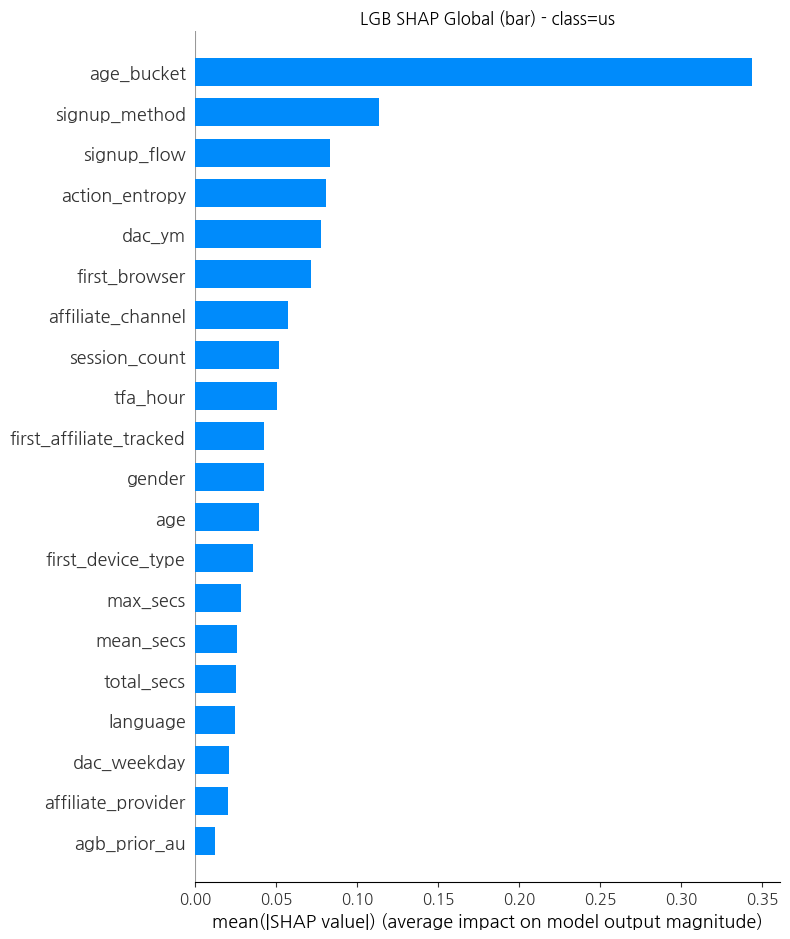

signup_flow                0.362556
dac_ym                     0.352261
tfa_hour                   0.277554
age                        0.201321
first_device_type          0.192836
first_browser              0.191429
signup_method              0.176715
affiliate_provider         0.170147
first_affiliate_tracked    0.167605
dac_weekday                0.162424
age_missing                0.160071
mean_secs                  0.151685
action_entropy             0.147533
affiliate_channel          0.145487
max_secs                   0.138177
age_bucket                 0.135934
session_count              0.132295
gender                     0.113834
total_secs                 0.105867
language                   0.068887
signup_app                 0.059281
agb_prior_au               0.035374
agb_prior_es               0.033729
agb_prior_pt               0.032457
agb_prior_gb               0.031173
agb_prior_it               0.030603
agb_prior_fr               0.029306
agb_prior_us               0

Top5 preds: [('us', 0.4506418765307857), ('ndf', 0.4451646090216665), ('other', 0.07137569603406245), ('gb', 0.012052609554247421), ('fr', 0.008433099285658599)]


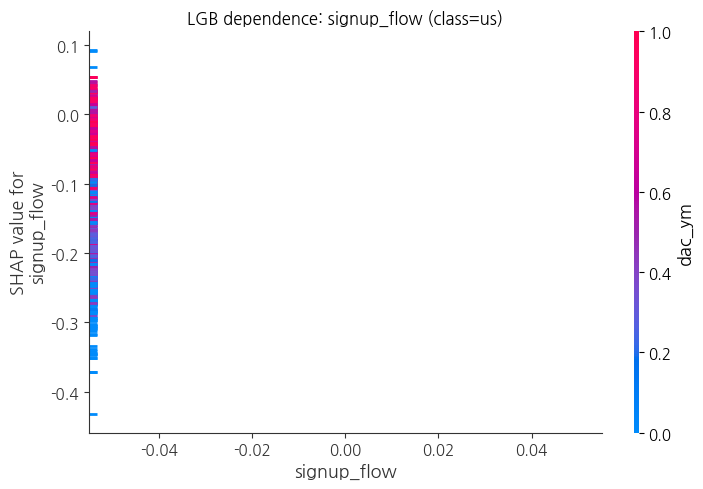

In [ ]:
!pip -q install shap
import shap

# 멀티클래스 SHAP 계산 (샘플링)
N = min(5000, len(X_val_lgb_shap))
Xv = X_val_lgb_shap.sample(N, random_state=42)

expl_lgb = shap.TreeExplainer(lgb_model)

shap_raw = expl_lgb.shap_values(Xv)
shap_by_class = to_classwise_shap(shap_raw, Xv)   # ✅ list[C] of (N,F)

print("Xv:", Xv.shape)
print("shap_by_class[0]:", shap_by_class[0].shape)
print("num classes:", len(shap_by_class))

# Global: 클래스별/전체 중요 피처
# 1) 클래스 하나 찍어서 보기 ('us')
target_class = "us"
k = classes.index(target_class)

shap.summary_plot(shap_by_class[k], Xv, plot_type="bar", show=False)
plt.title(f"LGB SHAP Global (bar) - class={target_class}")
plt.tight_layout()
plt.show()

# 2) 전체(클래스 평균 magnitude)로 통합 중요도 만들기
# shap_vals_lgb: list of (N, F)
abs_mean = np.mean([np.abs(sv).mean(axis=0) for sv in shap_by_class], axis=0)
lgb_global = pd.Series(abs_mean, index=Xv.columns).sort_values(ascending=False)
display(lgb_global.head(30))

# 3) Local: 특정 유저 1명 설명 (Top-k class 기준)
i = 0  # 설명할 row index in Xv (iloc)
x_one = Xv.iloc[[i]]

# 해당 row의 예측 확률
p = lgb_model.predict_proba(x_one)[0]
topk = np.argsort(p)[::-1][:5]
print("Top5 preds:", [(classes[j], float(p[j])) for j in topk])

# 4) 관계분석: dependence plot (피처간 상호작용 힌트)
feat = lgb_global.index[0]  # 가장 중요한 피처 하나
# 클래스 하나 기준으로 dependence (예: top class)
k = classes.index("us") if "us" in classes else 0

shap.dependence_plot(feat, shap_by_class[k], Xv, show=False)
plt.title(f"LGB dependence: {feat} (class={classes[k]})")
plt.tight_layout()
plt.show()

1) 클래스 하나 찍어서 보기 ('us')  
- Global SHAP (막대 그래프)  
"미국(us)을 예측하는 데 어떤 변수가 얼마나 영향을 주는가?"  
<br>
    - `age_bucket` 가장 영향력 큼  
    특정 연령대가 US 선택 확률을 크게 좌우  
    연령대별 여행 성향이 다름  
    모델이 “나이대”를 매우 강하게 활용 중  
    <br>  
    - `signup_method`  facebook / basic 차이  
    가입 방식에 따라 US 예약 확률 차이 존재  
    소셜 로그인 유저 vs 일반 가입 유저 행동 패턴 차이 가능  
    <br>  
    - `signup_flow` 가입 경로 단계  
    특정 flow를 거친 유저가 US 갈 확률이 높거나 낮음  
    마케팅 funnel과 관련 가능성 높음  
    <br>  
    - `action_entropy` 세션 행동 다양성  
    행동이 다양할수록(높은 entropy)  
    탐색형 유저 → 해외 목적지 확률 증가 가능  
    <br>  
    - `first_browser` / `first_device_type`  
    기기 환경도 영향 있음  
    모바일 vs 데스크탑 차이 존재  

<br>  

2) 전체(클래스 평균 magnitude)로 통합 중요도 만들기
$$
mean(∣SHAP∣)
$$

- 평균 영향 크기  
signup_flow 영향이 가장 큼  
action_entropy도 상위권  

<br>  

3) Local: 특정 유저 1명 row의 예측 확률 확인  
Top5 preds:  
[('us', 0.4506418765307857),  
('ndf', 0.4451646090216665),   
('other', 0.07137569603406245),  
('gb', 0.012052609554247421),  
('fr', 0.008433099285658599)]  

<br>  

4) 관계분석: dependence plot (피처간 상호작용 힌트)  
- signup_flow 특정 값에서 SHAP 값이 크게 음수  
→ 해당 flow는 US 예측에 불리  
<br>
- 특정 flow는 SHAP 값이 양수  
→ 그 경로 유입 유저는 US 갈 확률 높음  

<br>  

> <BIG>📌 모델은 “나이 + 가입경로 + 행동 다양성”을 가장 강하게 사용해 국가를 예측하고 있다.</BIG>

---

### 8-2-2. CatBoost 해석 (Global + Local + 관계)

In [133]:
from catboost import Pool

# 샘플링
N = min(5000, len(X_val))
Xv_cb = X_val.sample(N, random_state=42)

# 모델 feature 순서로 정렬
feat_names = cb_model.feature_names_
Xv_cb_fixed = Xv_cb[feat_names]

pool_cb = Pool(Xv_cb_fixed, cat_features=cat_cols)

# SHAP values
sv = cb_model.get_feature_importance(pool_cb, type="ShapValues")
sv = np.array(sv)
print("cb shap raw shape:", sv.shape)

C = len(classes)               # classes 개수
F = len(feat_names)            # feature 개수

# multiclass shape 정규화 -> (N, F, C)
if sv.ndim == 3:
    # case A: (N, C, F+1)
    if sv.shape[1] == C and sv.shape[2] == F + 1:
        sv_feat = sv[:, :, :-1]          # (N, C, F)
        sv_feat = np.transpose(sv_feat, (0, 2, 1))  # -> (N, F, C)

    # case B: (N, F+1, C)
    elif sv.shape[1] == F + 1 and sv.shape[2] == C:
        sv_feat = sv[:, :-1, :]          # (N, F, C)

    else:
        raise ValueError(f"Unknown multiclass SHAP shape: {sv.shape}")

elif sv.ndim == 2:
    # binary/1-class: (N, F+1)
    sv_feat = sv[:, :-1]                 # (N, F)
else:
    raise ValueError(f"Unexpected SHAP ndim: {sv.ndim}")

# 5) Global importance (mean |shap|)
if sv_feat.ndim == 3:
    cb_abs = np.abs(sv_feat).mean(axis=(0, 2))      # (F,)
else:
    cb_abs = np.abs(sv_feat).mean(axis=0)           # (F,)

cb_shap_global = pd.Series(cb_abs, index=feat_names).sort_values(ascending=False)
display(cb_shap_global.head(30))

cb shap raw shape: (5000, 12, 33)


dac_ym                     0.103165
first_browser              0.072582
tfa_hour                   0.068158
gender                     0.061221
age_bucket                 0.060282
first_affiliate_tracked    0.053987
signup_method              0.052818
age                        0.052420
first_device_type          0.051865
signup_flow                0.051727
action_entropy             0.045840
dac_weekday                0.038653
age_missing                0.038264
affiliate_channel          0.036327
affiliate_provider         0.034976
mean_secs                  0.033349
session_count              0.031222
max_secs                   0.021965
total_secs                 0.018506
agb_prior_us               0.017480
agb_prior_gb               0.016792
language                   0.015431
agb_prior_au               0.013930
agb_prior_ca               0.013164
agb_prior_it               0.012789
signup_app                 0.012591
agb_prior_fr               0.011191
agb_prior_de               0

- Global CatBoost  
LightGBM과 거의 동일한 패턴을 학습 중  
<br>  
    - `age_bucket` 가장 강력한 변수  
    → 연령대가 국가 예측에 핵심  
    <br>  
    - `dac_ym`  가입 연-월  
    → 시즌성 영향 존재  
    → 여름/겨울 여행 패턴 반영  
    <br>  
    - `first_browser`  
    → 브라우저가 의외로 강함  
    → Safari / Chrome 사용자 행동 차이  
    <br>  
    - `tfa_hour` 첫 활동 시간  
    → 밤 vs 낮 사용자 성향 다름  
    <br>  
    - action_entropy  세션 다양성  
    → 탐색형 유저 vs 바로 예약형 유저 차이 반영  
    <br>  
    - sessions 관련 변수  
    `mean_secs`, `session_count`, `max_secs`  
    → 세션 길이도 의미 있음  

📌 feature engineering 방향이 맞았음을 확인  

age_bucket                 0.207527
session_count             -0.172453
total_secs                -0.112282
action_entropy             0.081769
age_missing                0.074417
age                       -0.062346
dac_ym                     0.059231
first_affiliate_tracked    0.045559
tfa_hour                   0.044575
signup_flow               -0.038763
agb_prior_us              -0.029398
agb_prior_it               0.021877
first_device_type         -0.015657
first_browser             -0.013183
mean_secs                  0.011609
dtype: float64

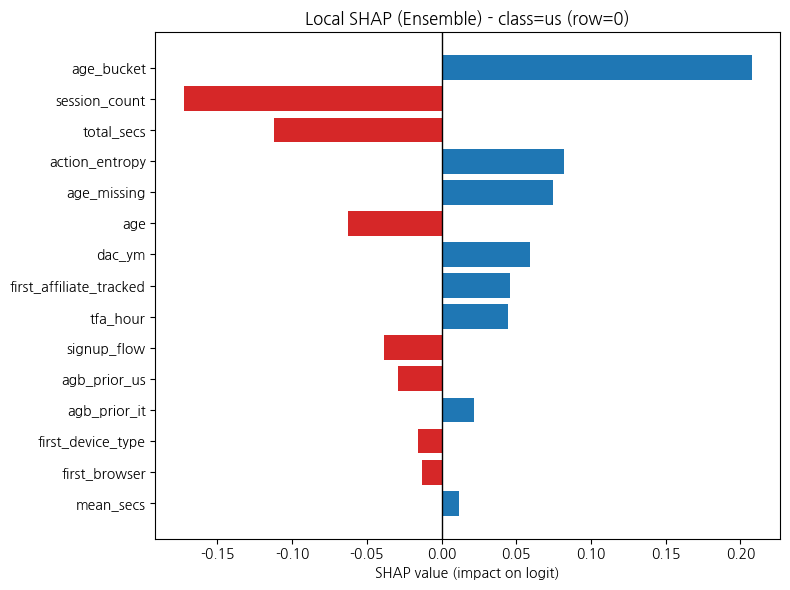

In [144]:
shap_cb = sv_feat

# “특정 클래스(예: us)”에 대한 Local Top 영향 변수(샘플 1개)
def get_class_index(classes, target_class):
    classes = [str(c).lower() for c in classes]
    return classes.index(target_class.lower())

target_class = "us"   # 보고 싶은 국가로 바꿔
k = get_class_index(classes, target_class)

# shap_values가 list인지/ndarray인지 케이스 분기
def shap_class_slice(shap_values, class_idx):
    if isinstance(shap_values, list):
        return shap_values[class_idx]
    # ndarray: (n_samples, n_features, n_classes) or (n_classes, n_samples, n_features) 등 다양
    arr = np.asarray(shap_values)
    if arr.ndim == 3 and arr.shape[2] == len(classes):
        return arr[:, :, class_idx]
    if arr.ndim == 3 and arr.shape[0] == len(classes):
        return arr[class_idx]
    raise ValueError("Unknown SHAP multiclass shape:", arr.shape)

sh_lgb_k = shap_class_slice(shap_lgb, k)  # (n_samples, n_features)
sh_cb_k  = shap_class_slice(shap_cb,  k)

# 앙상블 shap (가중합)
sh_ens_k = w_lgb * sh_lgb_k + (1 - w_lgb) * sh_cb_k

# 한 명(local) 설명
i = 0  # 보고 싶은 validation row index
local = pd.Series(sh_ens_k[i], index=X_val.columns).sort_values(key=np.abs, ascending=False)
display(local.head(15))

# 상위 15개 (이미 abs 기준 정렬된 상태)
topn = 15
local_top = local.head(topn)

plt.figure(figsize=(8,6))
colors = ["#1f77b4" if v > 0 else "#d62728" for v in local_top.values]

plt.barh(local_top.index[::-1], local_top.values[::-1], color=colors[::-1])
plt.axvline(0, color="black", linewidth=1)

plt.title(f"Local SHAP (Ensemble) - class={target_class} (row={i})")
plt.xlabel("SHAP value (impact on logit)")
plt.tight_layout()
plt.show()

- SHAP 값 의미:  
양수(+) → US로 갈 확률을 올리는 요인  
음수(-) → US 확률을 낮추는 요인  


🔵 US로 가는 방향으로 밀어준 요인 (상위 +)  
    `age_bucket` : +0.207 /	특정 연령대가 US 선호 경향  
    `action_entropy` : +0.082 /	행동 다양성 높음 → 여행 의도 뚜렷  
    `age_missing` : +0.074 /	나이 정보 결측 패턴이 US쪽과 연관  
    `dac_ym` : +0.059 /	가입 시점(월)이 US 성수기/패턴과 유사  
    `first_affiliate_tracked` : +0.046 / 특정 유입 트래킹 경로가 US와 관련  
    `tfa_hour` : +0.045 / 첫 활동 시간대 패턴  
👉 연령대 + 가입 시점 + 행동 다양성이 핵심적으로 US 방향으로 작용  

🔴 US 확률을 낮춘 요인 (상위 -)  
    `session_count` : -0.172 / 세션 수 많음 → 오히려 US보단 다른 나라 성향  
    `total_secs` : -0.113 / 총 체류시간 많음 → 비교 탐색형 유저  
    `age` : -0.062 / 실제 나이 수치가 US 평균과 다름  
    `signup_flow` : -0.039 / 가입 플로우 패턴이 US와 약간 다름  
    `agb_prior_us` : -0.029 / country prior 상 US 기대값은 오히려 낮게 작용  
👉 `session_count` / `total_secs`가 US 확률을 깎음  
👉 많이 탐색하는 유저는 US보다 유럽/other 쪽으로 가는 경향이 학습됨  

<br>

- Local 확인 (특정 유저)  
이 유저는 이 조합이 미국 여행 패턴과 유사해서 US 쪽으로 밀림  
    - 특정 연령대(age_bucket)  
    - 행동 패턴 다양성 높음(action_entropy)  
    - 가입 시점(dac_ym) 
    - 첫 활동 시간(tfa_hour)  
→ 하지만 세션 수 많고 총 체류시간 길고  
→ 여러 나라를 비교 탐색하는 성향이라 US 확률을 일부 낮춤  
→ US 47% vs NDF 34% 으로 완전히 압도적이진 않지만 US가 근소 우세한 구조 확인  

<br>

👉 프로젝트 목적:  
"어떤 환경(기기)에서 어떤 경로로 들어온, 몇 살의 유저가 어디를 갈까?"  

지금 SHAP 결과를 보면 아래가 상위에 올라와 있음    
✔ 연령대  
✔ 가입 시점  
✔ 세션 행동 패턴  
✔ 유입 경로  

→ 모델 설계 방향이 맞음을 확인

---

## 8-3. 관계 분석

### 8-3-1. Global Feature Importance

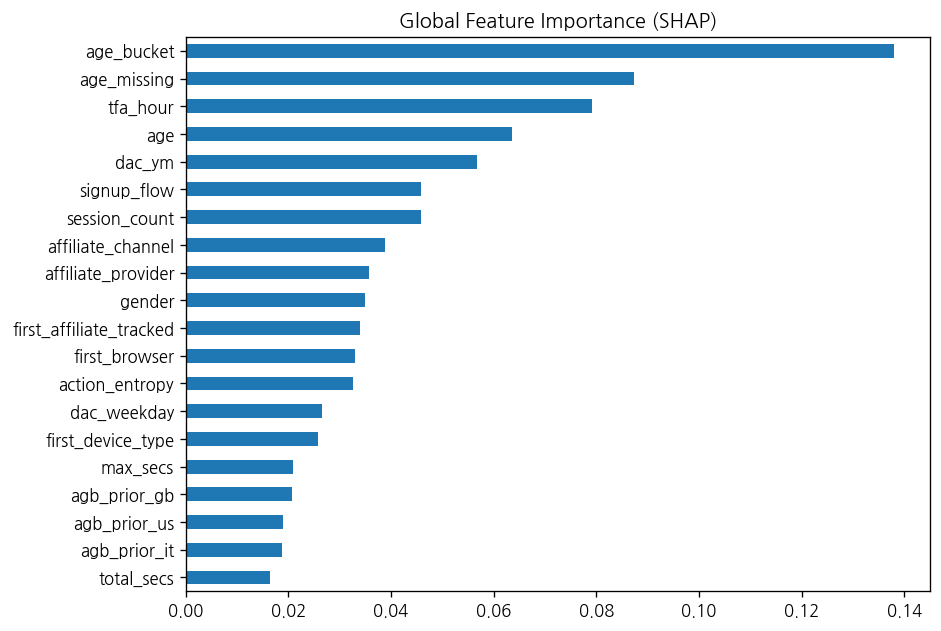

In [212]:
# shap 값이 (n, f, c) 라고 가정
k = [str(c).lower() for c in classes].index("us")

global_importance = np.abs(shap_cb[:, :, k]).mean(axis=0)

imp = pd.Series(global_importance, index=X_val.columns)
imp = imp.sort_values(ascending=False)

plt.figure(figsize=(8,6))
imp.head(20).sort_values().plot(kind="barh")
plt.title("Global Feature Importance (SHAP)")
plt.show()

### 8-3-2. 수치컬럼

In [218]:
def pdp_2d_numeric_ensemble(
    X,
    X_tr,
    f1,
    f2,
    target_class,
    classes,
    cat_cols,
    lgb_model,
    cb_model,
    w_lgb,
    sample_n=3000,
    grid_n=20
):
    # 클래스 인덱스
    k = [str(c).lower() for c in classes].index(target_class.lower())

    # 속도 위해 샘플링
    if sample_n is not None:
        X0 = X.sample(min(sample_n, len(X)), random_state=42).copy()
    else:
        X0 = X.copy()

    # 분위수 기반 grid
    g1 = np.linspace(X0[f1].quantile(0.05),
                     X0[f1].quantile(0.95),
                     grid_n)

    g2 = np.linspace(X0[f2].quantile(0.05),
                     X0[f2].quantile(0.95),
                     grid_n)

    Z = np.zeros((len(g1), len(g2)))

    for i, v1 in enumerate(g1):
        for j, v2 in enumerate(g2):
            Xtmp = X0.copy()
            Xtmp[f1] = v1
            Xtmp[f2] = v2

            p = predict_proba_ensemble_safe(
                Xtmp,
                X_tr,
                cat_cols,
                lgb_model,
                cb_model,
                w_lgb
            )[:, k].mean()

            Z[i, j] = p

    # ---- Heatmap ----
    plt.figure(figsize=(7,6))
    sns.heatmap(
        Z,
        xticklabels=np.round(g2, 2),
        yticklabels=np.round(g1, 2),
        cmap="viridis"
    )
    plt.xlabel(f2)
    plt.ylabel(f1)
    plt.title(f"2D PDP (Ensemble): {f1} × {f2}")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(Z, index=np.round(g1,2), columns=np.round(g2,2))

- 세션시간 & 나이

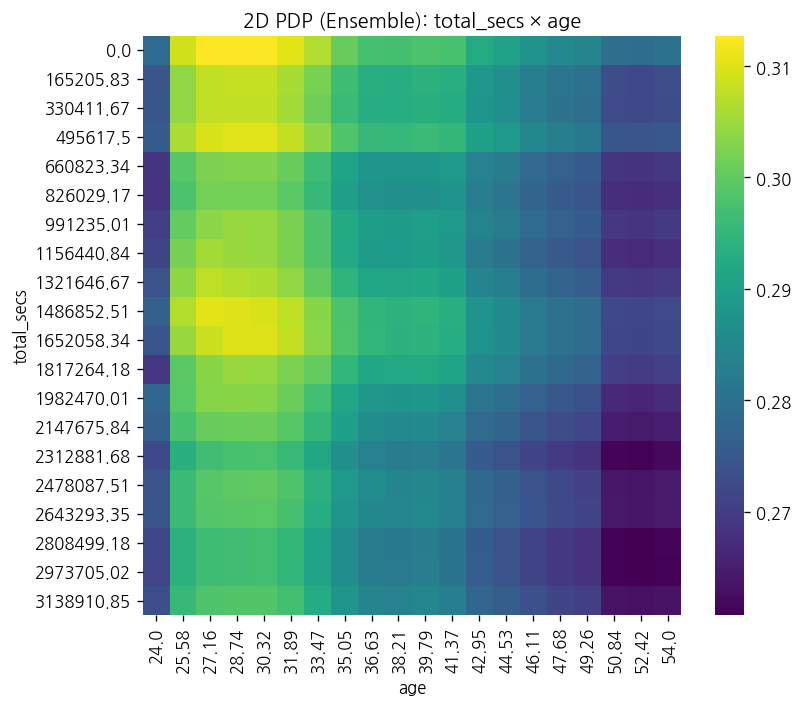

,24.00,25.58,27.16,28.74,30.32,31.89,33.47,35.05,36.63,38.21,39.79,41.37,42.95,44.53,46.11,47.68,49.26,50.84,52.42,54.00
0.00,0.278638,0.308954,0.312699,0.312524,0.312444,0.310352,0.306489,0.300533,0.297424,0.297082,0.297978,0.297515,0.292533,0.290745,0.286940,0.285195,0.284127,0.279490,0.279033,0.280289
165205.83,0.274114,0.303991,0.307727,0.308137,0.308145,0.305899,0.301959,0.296475,0.293530,0.293146,0.293859,0.293490,0.288280,0.286611,0.282936,0.280936,0.279851,0.272663,0.272223,0.272954
330411.67,0.274594,0.304109,0.307802,0.307648,0.307672,0.305471,0.301310,0.295939,0.293133,0.292946,0.293573,0.292775,0.287948,0.286301,0.282593,0.280544,0.279422,0.272333,0.271909,0.272711
495617.50,0.275573,0.306118,0.309617,0.310075,0.310088,0.307954,0.303798,0.298405,0.295529,0.295353,0.296035,0.295223,0.290294,0.288652,0.284949,0.282931,0.281760,0.274535,0.274133,0.274912
660823.34,0.268803,0.298973,0.302467,0.302870,0.302885,0.300672,0.296542,0.291071,0.288084,0.287838,0.287991,0.288600,0.283733,0.282086,0.278402,0.276688,0.275566,0.268679,0.268280,0.269079
826029.17,0.268578,0.298056,0.301678,0.301666,0.301667,0.299483,0.295516,0.289854,0.286827,0.286591,0.286518,0.287371,0.282531,0.280854,0.277218,0.275339,0.274227,0.267496,0.267103,0.267901
991235.01,0.269975,0.300121,0.303760,0.304574,0.304381,0.302235,0.298162,0.292384,0.289470,0.289220,0.289656,0.288905,0.283880,0.282232,0.278615,0.276653,0.275537,0.268862,0.268436,0.269235
1156440.84,0.271325,0.301795,0.305532,0.304604,0.304388,0.302226,0.298120,0.292055,0.289177,0.288934,0.289397,0.288152,0.282280,0.280573,0.276952,0.275113,0.273995,0.267348,0.266935,0.267725
1321646.67,0.273716,0.303913,0.307450,0.306645,0.306375,0.304154,0.299997,0.294594,0.291441,0.291176,0.291660,0.290440,0.284452,0.282671,0.279049,0.277222,0.276077,0.269318,0.268919,0.269715
1486852.51,0.276369,0.306611,0.310448,0.309903,0.309648,0.307550,0.303364,0.297877,0.294625,0.294049,0.294528,0.293317,0.287405,0.285612,0.281969,0.280086,0.278928,0.272024,0.271623,0.272455


In [220]:
pdp_2d_numeric_ensemble(
    X=X_val,
    X_tr=X_tr,
    f1="total_secs",
    f2="age",
    target_class="us",
    classes=classes,
    cat_cols=cat_cols,
    lgb_model=lgb_model,
    cb_model=cb_model,
    w_lgb=w_lgb,
    sample_n=3000,
    grid_n=20
)

---

### + 예시 : 미국 / 가입경로 & 첫 기기  

In [147]:
# 위에서 구한 가중치
w_lgb = 0.17

ens_val = w_lgb * lgb_val_prob + (1 - w_lgb) * cb_val_prob

print("ens_val shape:", ens_val.shape)

ens_val shape: (42691, 12)


In [202]:
def avg_prob_by_group(X, prob, classes, target_class, group_cols, min_n=200):
    k = get_class_index(classes, target_class)
    df = X[group_cols].copy()
    df["p"] = prob[:, k]
    out = (df.groupby(group_cols)
             .agg(n=("p","size"), p_mean=("p","mean"))
             .reset_index()
          )
    return out[out["n"] >= min_n].sort_values("p_mean", ascending=False)

# ens_val 확률로 분석(앙상블 기준)
group_result = avg_prob_by_group(
    X_val,
    ens_val,
    classes,
    "us",
    group_cols=["signup_method", "first_device_type"],
    min_n=200
)

display(group_result.head(20))

,signup_method,first_device_type,n,p_mean
5,basic,mac desktop,12423,0.340490
14,facebook,mac desktop,5404,0.316353
8,basic,windows desktop,10661,0.297005
17,facebook,windows desktop,3892,0.275202
3,basic,ipad,2179,0.265351
13,facebook,iphone,1168,0.247139
12,facebook,ipad,629,0.242780
4,basic,iphone,3006,0.223463
6,basic,other/unknown,1622,0.222055
0,basic,android phone,349,0.205734


- “US 확률이 높은 조합” = US 타겟 캠페인 우선순위 세그먼트를 의미  

<br>  

- 1위 : basic + mac desktop / n = 12423 / p_mean = 0.340  
→ Mac Desktop + 기본 가입 유저가 US 확률 가장 높음  
    - 표본도 매우 많음 (12K)  
    - 평균 34% / 전체 평균보다 상당히 높은 그룹일 가능성 큼  
    - 실전 마케팅 타겟 1순위  

<br>  

- 2위 : facebook + mac desktop / p_mean = 0.316  
→ Mac Desktop이면 가입 방식 상관없이 US 성향 강함  
(Mac Desktop이면 가입 방식 상관없이 US 성향 강함)  

<br>  

- 3~4위 : basic + windows desktop  (0.297) / facebook + windows desktop (0.275)  
→ 데스크탑 유저는 전반적으로 US 성향이 강함  

<br>  

- 하위 세그먼트 : facebook + other/unknown : p_mean = 0.163  
→ 이 조합은 US 확률이 매우 낮음 / US 캠페인 타겟에서 제외 가능  


---

# 9️⃣ 결과

**1. 최종 모델 성능**  
LightGBM + CatBoost 앙상블에 countries 파일의 prior를 소폭(0.03) 반영한 결과,  
다음과 같은 최종 성능을 달성하였다.  

- Best NDCG@5: 0.82824  
- Best Accuracy: 0.64281  
- Best weight: (LGB+CB ensemble, prior = 0.03)  

이는 단일 CatBoost 모델(NDCG@5 ≈ 0.8279) 대비 소폭 향상된 성능으로  
과도한 prior 반영 없이, 데이터 기반 예측을 유지하면서 분포 보정 효과만 부분 반영한 결과  

👉 즉, 모델 예측 확률에 국가 사전 분포(prior)를 “약하게” 섞는 것이 가장 효과적이었다.

<br>  

**2. 주요 변수 중요도 분석**  
모델 해석(Feature Importance, SHAP)을 통해 다음 변수들이 핵심 결정 요인으로 확인되었다.  

- ① 시점 효과 (Temporal Effect) – 가장 강함  
`dac_ym`, `dac_weekday`, `tfa_hour`  
시즌성 + 시간대 트래픽 특성 반영  
국가 수요는 강한 시계열 구조를 가짐  
👉 “언제 가입했는가”가 1차 분기점  

- ② 2축: 행동 강도 (Engagement)  
`total_secs`, `session_count`, `mean/max_secs`, `action_entropy`  
👉 “얼마나 탐색했는가”가 2차 분기점  
(탐색 강도가 높을수록 특정 국가로 수렴)  

- ③ 3축: 가입 맥락(Context)  
`signup_method`, `affiliate_channel`, `first_device_type`, `first_browser`, `language`  
👉 어떤 채널/디바이스/언어 환경에서 들어왔는가  

- ④ 4축: Prior (보정 신호)  
`agb_prior_*`  
국가 통계 기반 신호  
행동 데이터의 불확실성 보완  

<br>

**3. 종합 해석**   

🔎 모델 관점  
트리 기반 부스팅 모델(LGBM, CatBoost)이 선형 모델 대비 우수  
두 모델 앙상블이 단일 모델보다 안정적  
국가 prior를 0.03 수준으로만 반영했을 때 최적 성능  

최종 NDCG@5 ≈ 0.8282  
이는 모델이 데이터 패턴을 충분히 학습하고 있으며  
과도한 분포 보정 없이도 일반화 성능이 높음을 의미  

<br>

**4. 비즈니스적 시사점**   
- “행동 데이터” : 사용자의 실제 활동량(total_secs, 세션 수 등)이 국가 예측에 중요한 변수  
가입 직후의 초기 행동 데이터를 실시간으로 수집/반영하는 것이 중요  
첫 세션 행동 기반 “초기 국가 추천 로직” 구축 가능  
활동성이 높은 사용자에게는 주요 국가(US 등) 우선 노출 전략 가능  
유입 채널 기반 맞춤 추천 전략 가능  
<br>  
- affiliate_channel, signup_method  
채널별 국가 선호 패턴 분석 → 채널 맞춤형 랜딩 국가 추천  
마케팅 캠페인과 연계한 국가 추천 전략 수립 가능  
특정 채널에서 유입된 사용자에게 해당 국가를 상단 배치  
<br>  
- 연령 기반 세그먼트 전략 : 연령이 주요 변수이며, 활동성과 상호작용 효과 존재  
연령대별 인기 국가 분석 → 연령 세그먼트별 Top-N 추천  
20~30대 vs 40대 이상 등 차별화된 국가 노출 전략 가능  
<br>  
- 시즌성/가입 시점 활용 : 가입 연월(dac_ym)이 중요한 변수  
시즌별 인기 국가 자동 반영 추천 시스템 가능  
성수기/비수기별 추천 로직 차별화  
국가 트렌드 변화 감지 시스템 구축 가능  
<br>  
- Prior를 “약하게” 반영하는 것이 효과적  
과거 국가 분포를 완전히 따르기보다 모델 예측을 중심으로 하되,  
데이터 부족/불확실성 구간에서만 분포 보정이 효과적  
→ 완전 rule-based 접근이 아니라  
→ ML 중심 + 통계적 보정의 하이브리드 전략이 최적  

---